# Description

Drafts for the finalized versions of the paper figures

# Load analysis functions

In [1]:
%run ....../imports.ipynb
%run ....../analysisScripts/snotelAnalysisFunctions.ipynb


Path where data is located

In [35]:
#
pathToLoad = '...../data/figureData'

# Figure 1

Panel showing station locations, scatter points colored by climatological peak SWE (calculated in stationOverview.ipynb)

Panel showing peak SWE histogram of the SWE climatological seasonal cycles from all stations (calculated in sweUniversal.ipynb)

In [25]:
### Load Peak SWE data ###
peakSWEData = np.load(pathToLoad + '/figure1MaxSWE.npz')

lats = peakSWEData['lats']
lons = peakSWEData['lons']
metrics = peakSWEData['peakSWE']

### Load the SWE timeseries data ###
sweTimeSeriesData = np.load(pathToLoad + '/figure1SWECurvesDim_Climatology.npz')
Xmean = sweTimeSeriesData['Xmean']
Ymean = sweTimeSeriesData['Ymean']
tt = sweTimeSeriesData['tt']
bb = sweTimeSeriesData['bb']
allHist = sweTimeSeriesData['allHist']

/tmp/ipykernel_180943/2651406234.py:14: RuntimeWarning: divide by zero encountered in log2
  c = ax1.pcolormesh(tt,bb,np.log2(allHist.T),cmap=cmap,norm=norm)#np.append([],[2**i for i in range (2,8,1)]))
/tmp/ipykernel_180943/2651406234.py:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


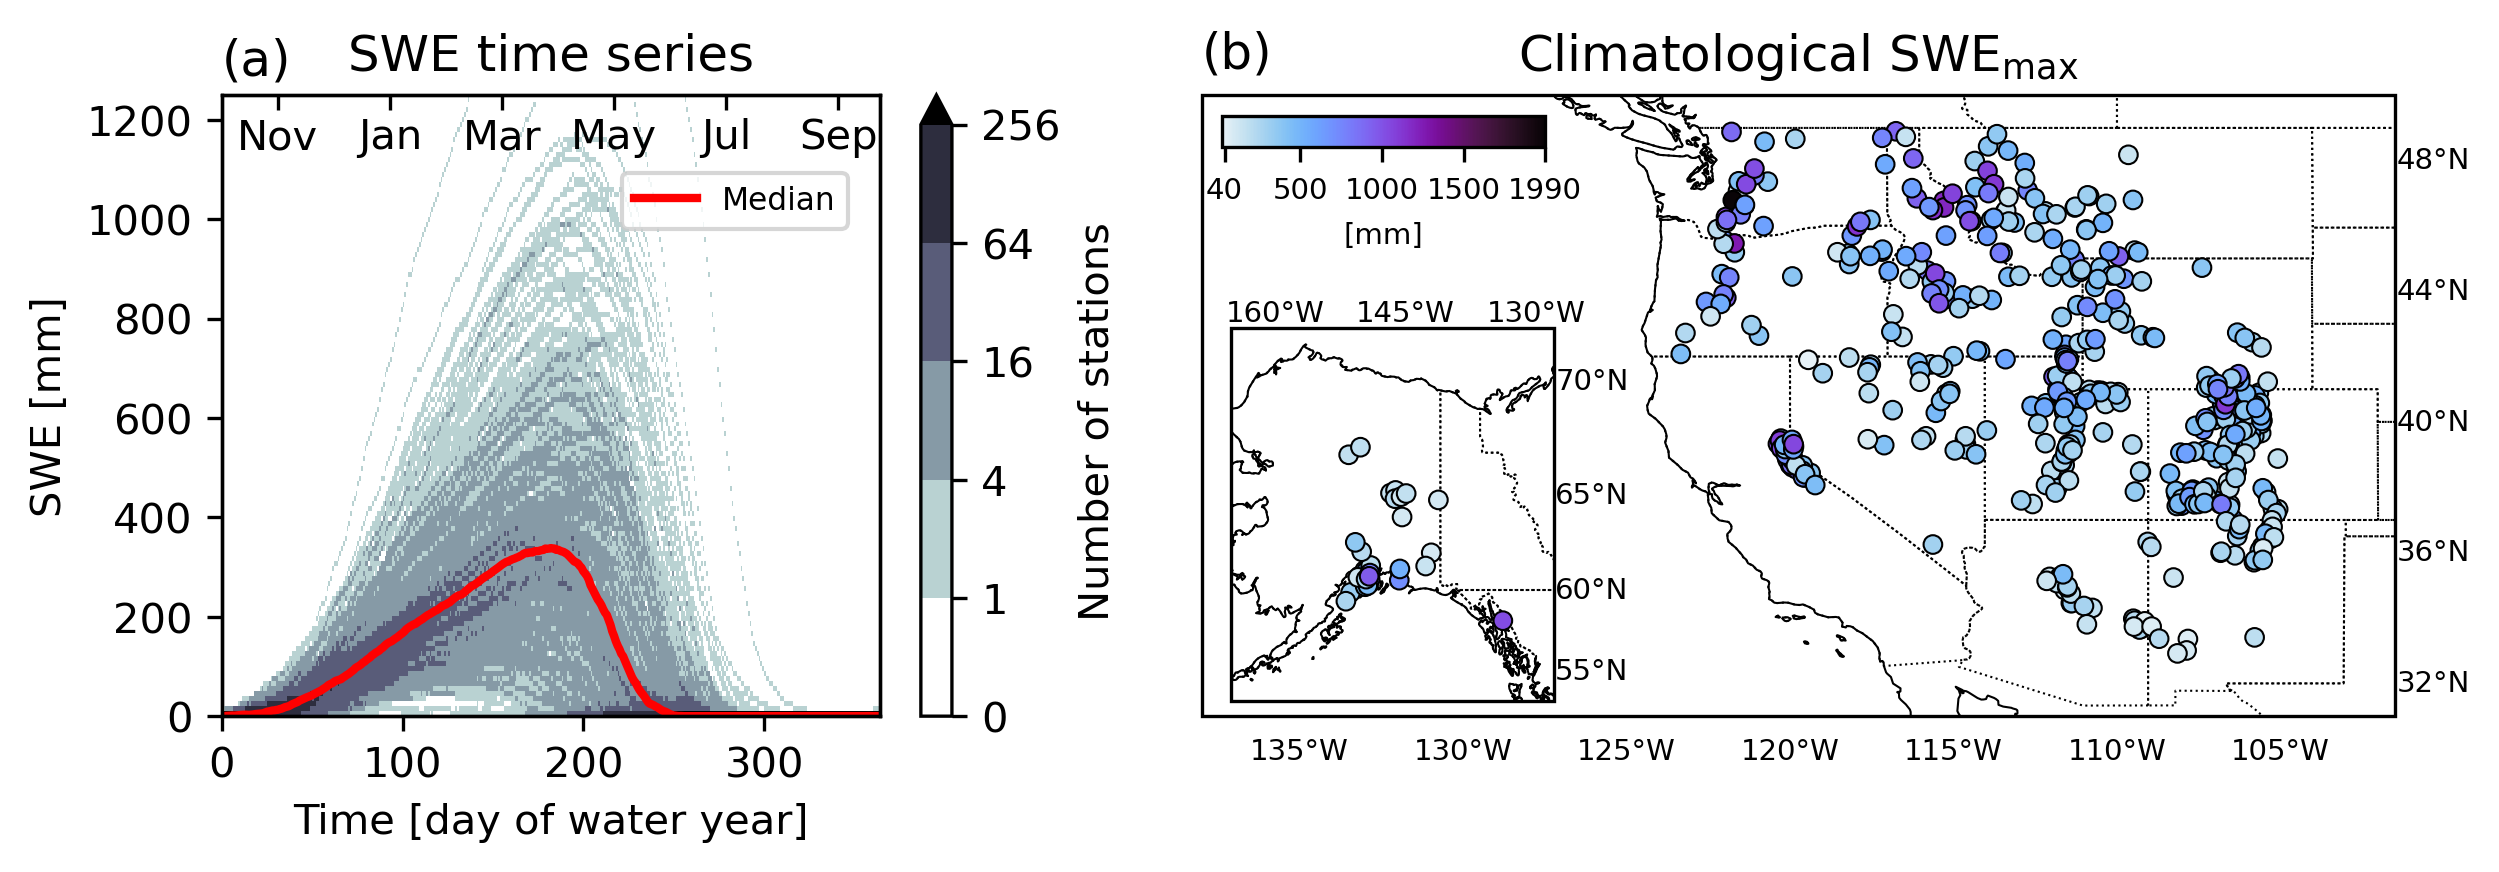

In [5]:
fig = plt.figure(figsize=(8.5,3),dpi=300)
gs = GridSpec(1, 2, width_ratios=[1,1.5])

## SWE Time Series Histogram ##

ax1 = fig.add_subplot(gs[0])
plt.subplots_adjust(hspace=-8)

levels = MaxNLocator(nbins=5).tick_values(-1, 8)
cmap = plt.colormaps['bone_r']
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=False,extend='max')


c = ax1.pcolormesh(tt,bb,np.log2(allHist.T),cmap=cmap,norm=norm)#np.append([],[2**i for i in range (2,8,1)]))
cbar = plt.colorbar(c,label='Number of stations')
cbar.ax.set_yticklabels(['0']+[str(round(2**i)) for i in levels[1:]])
ax1.plot(Xmean,Ymean,linewidth=2,c='r',label='Median')
ax1.set_ylabel(r'SWE [mm]')
ax1.set_xlabel('Time [day of water year]')
ax1.set_ylim([0,1250])
ax1.set_xticks(np.arange(0,400,100))
ax1.set_xlim([0,364])

ax2 = ax1.twiny()
ax2.set_xlim([0,364])
ax2.set_xticks(np.arange(0,359,62)+31)
ax2.set_xticklabels(['Nov','Jan','Mar','May','Jul','Sep'],rotation=0);
ax2.tick_params(axis="x",direction="in",pad=-15)

ax1.legend(loc='upper right', bbox_to_anchor=(0.975, 0.9),fontsize=7.5)
ax1.set_title('SWE time series')
ax1.text(0,1290,'(a)',fontsize=12);


#############################################
## Max SWE plot ##

# Continental US Stations #
ax0 = fig.add_subplot(gs[1], projection=ccrs.PlateCarree())

# Add coastlines
ax0.coastlines(linewidth=0.5,zorder=-1)

# Add U.S. state borders
ax0.add_feature(cfeature.STATES, linestyle=':', edgecolor='black', linewidth=0.5,zorder=-1)
gl = ax0.gridlines(crs=ccrs.PlateCarree(), draw_labels=True)
gl.xlines = False
gl.ylines = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.top_labels = False
gl.left_labels = False
gl.ylocator = mticker.FixedLocator(np.arange(32,54,4))
gl.xlabel_style = {'size': 7, 'color': 'k', 'va':'top'}
gl.ylabel_style = {'size': 7, 'color': 'k', 'ha':'right'}

cmap = cmr.get_sub_cmap('cmr.voltage_r', 0.05, 0.95)

scatterSize = 20

sc = ax0.scatter(lons,lats,scatterSize,
                 c=metrics,cmap=cmap,edgecolor='k',linewidth=.5,zorder=0)

# Alaska stations #
axins = ax0.inset_axes(bounds = [-.14,0.025,0.6,.6],projection=ccrs.Mercator())
axins.scatter(lons,lats,scatterSize,
              c=metrics,cmap=cmap,edgecolor='k',linewidth=.5,transform=ccrs.PlateCarree(),zorder=0)
axins.coastlines(linewidth=0.5,zorder=-1)
axins.add_feature(cfeature.STATES, linestyle=':', edgecolor='black', linewidth=0.5,zorder=-1)
lon1, lon2, lat1, lat2 = -165, -128, 53, 72
axins.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
gl = axins.gridlines(crs=ccrs.PlateCarree(), draw_labels=True)
gl.xlines = False
gl.ylines = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.bottom_labels = False
gl.left_labels = False
#gl.ylocator = mticker.FixedLocator(np.arange(55,75,5))
gl.xlabel_style = {'size': 7, 'color': 'k', 'va':'top'}
gl.ylabel_style = {'size': 7, 'color': 'k', 'ha':'right'}


cbarTicks = np.array([40,500,1000,1500,1990])

# add colorbar
cbaxes = inset_axes(ax0,
    width="27%",  # width: 50% of parent_bbox width
    height="5%",  # height: 5%
    loc="upper left",
)
cbaxes.xaxis.set_ticks_position("bottom")
cbar = fig.colorbar(sc,cax=cbaxes,#label='Climatological Peak SWE (mm)'
            orientation='horizontal')
cbar.set_ticks(cbarTicks)
cbar.ax.tick_params(labelsize=7)
cbar.set_label('[mm]',size=7)

ax0.set_title(r'Climatological SWE$_\mathdefault{max}$')

lon1, lon2, lat1, lat2 = -138, -101.5, 31, 50
ax0.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())

ax0.text(-138,50.85,'(b)',fontsize=12)

#############################################


plt.tight_layout()

saveFigBool = 0
if saveFigBool:
    plt.savefig(f'...../finalizedFigures/figure1_stationSWEClim_timeseries.pdf')

# Figure 2: $k(t)$

Show the time series of $k(t)$, the degree-day factor. Values are computed in deduceKEmpirically.ipynb

In [7]:
### Load data ###
pathToLoad = '/home/nicknish/snowpack/snowTauFPw/data/figureData'
kData = np.load(pathToLoad + '/figure2_k.npz',allow_pickle=True)

datesForPlot = kData['datesForPlot']
binCenters = kData['binCenters']
hist2d = kData['hist2d']

## Also load the median k(t) ##
kMedian = np.load(pathToLoad + '/figure2_kMedian.npy')

## Load the station count data ##
kCount = np.load(pathToLoad + '/figure2_kCount.npz')
numberOfMeltyStations = kCount['numberOfMeltyStations']

In [8]:
## Smooth kMedian ##
# 30-day running mean
kMedianSmooth = movingAverage(np.append(np.append(kMedian,kMedian),kMedian),30)[366:366+366]

/tmp/ipykernel_180943/3862460290.py:11: RuntimeWarning: divide by zero encountered in log
  ctf = ax0.contourf(datedate,binbin,np.log(hist2d),levels=30,cmap=cmap)
/tmp/ipykernel_180943/3862460290.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels(['Oct','Nov','Dec','Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep'],rotation=90,fontsize=figFontSize)
/tmp/ipykernel_180943/3862460290.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(['Oct','Nov','Dec','Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep'],rotation=90,fontsize=figFontSize)


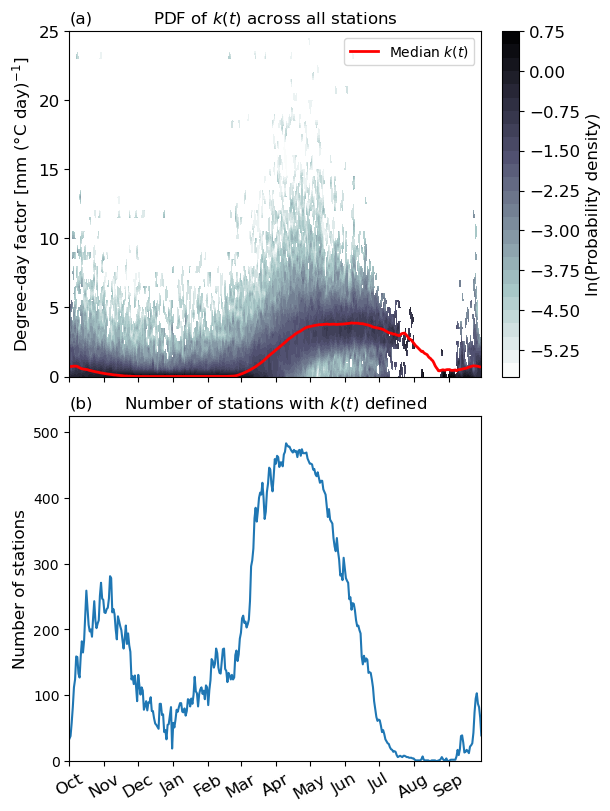

In [9]:
datedate,binbin = np.meshgrid(datesForPlot,binCenters)

### Set up figure ###
fig, axs = plt.subplots(2, 1, figsize=(6, 8), sharex=True, layout='constrained')
figFontSize = 12
ax0=axs[0]
ax1=axs[1]

## Plot histogram of k across all stations ##
cmap = 'bone_r'#cmr.get_sub_cmap('cmr.neutral', 0.05, 0.95)
ctf = ax0.contourf(datedate,binbin,np.log(hist2d),levels=30,cmap=cmap)
ax0.set_xticklabels(['Oct','Nov','Dec','Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep'],rotation=90,fontsize=figFontSize)
ax0.tick_params(axis='x', labelrotation=0)
ax0.tick_params(axis='both', labelsize=figFontSize)
cbar = plt.colorbar(ctf)
cbar.ax.tick_params(labelsize=figFontSize)
cbar.set_label(label='ln(Probability density)',fontsize=figFontSize)
ax0.set_ylabel(r'Degree-day factor [mm $(\degree \text{C day})^{-1}$]',fontsize=figFontSize)
ax0.set_ylim([0,25])

ax0.plot(datesForPlot,kMedianSmooth,linewidth=2,c='r',label=r'Median $k(t)$')
ax0.set_title('PDF of $k(t)$ across all stations',fontsize=figFontSize)
ax0.text(datetime.datetime(1999, 10, 1, 0, 0),25.6,'(a)',fontsize=figFontSize)
ax0.legend()

## Plot count of stations contributing to median on each date ##
ax1 = plt.subplot(2,1,2)
ax1.plot(datesForPlot,numberOfMeltyStations)
ax1.set_xticklabels(['Oct','Nov','Dec','Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep'],rotation=90,fontsize=figFontSize)
ax1.tick_params(axis='x', labelrotation=30)
ax1.set_xlim([min(datesForPlot),max(datesForPlot)])
#ax1.set_ylim([0,850])
ax1.set_ylabel(r'Number of stations',fontsize=figFontSize)
ax1.set_title(fr'Number of stations with $k(t)$ defined',fontsize=figFontSize)
ax1.set_ylim([0,525])
ax1.text(datetime.datetime(1999, 10, 1, 0, 0),537,'(b)',fontsize=figFontSize)

saveFigBool = False
if saveFigBool:
    plt.savefig('..../figure2_k.pdf',bbox_inches='tight')

# Figure 3

$R^2$ values between model and observations. Data for this figure is calculated in modelHeirarchy.ipynb.

## Analytic Model Only

In [10]:
### Load analytic model and observation data ###
analyticModelData = np.load(pathToLoad + '/figure3Analytic.npz')

analyticStation=analyticModelData['analyticStation']
analyticWY = analyticModelData['analyticWY']
obsStation = analyticModelData['obsStation']
obsWY = analyticModelData['obsWY']

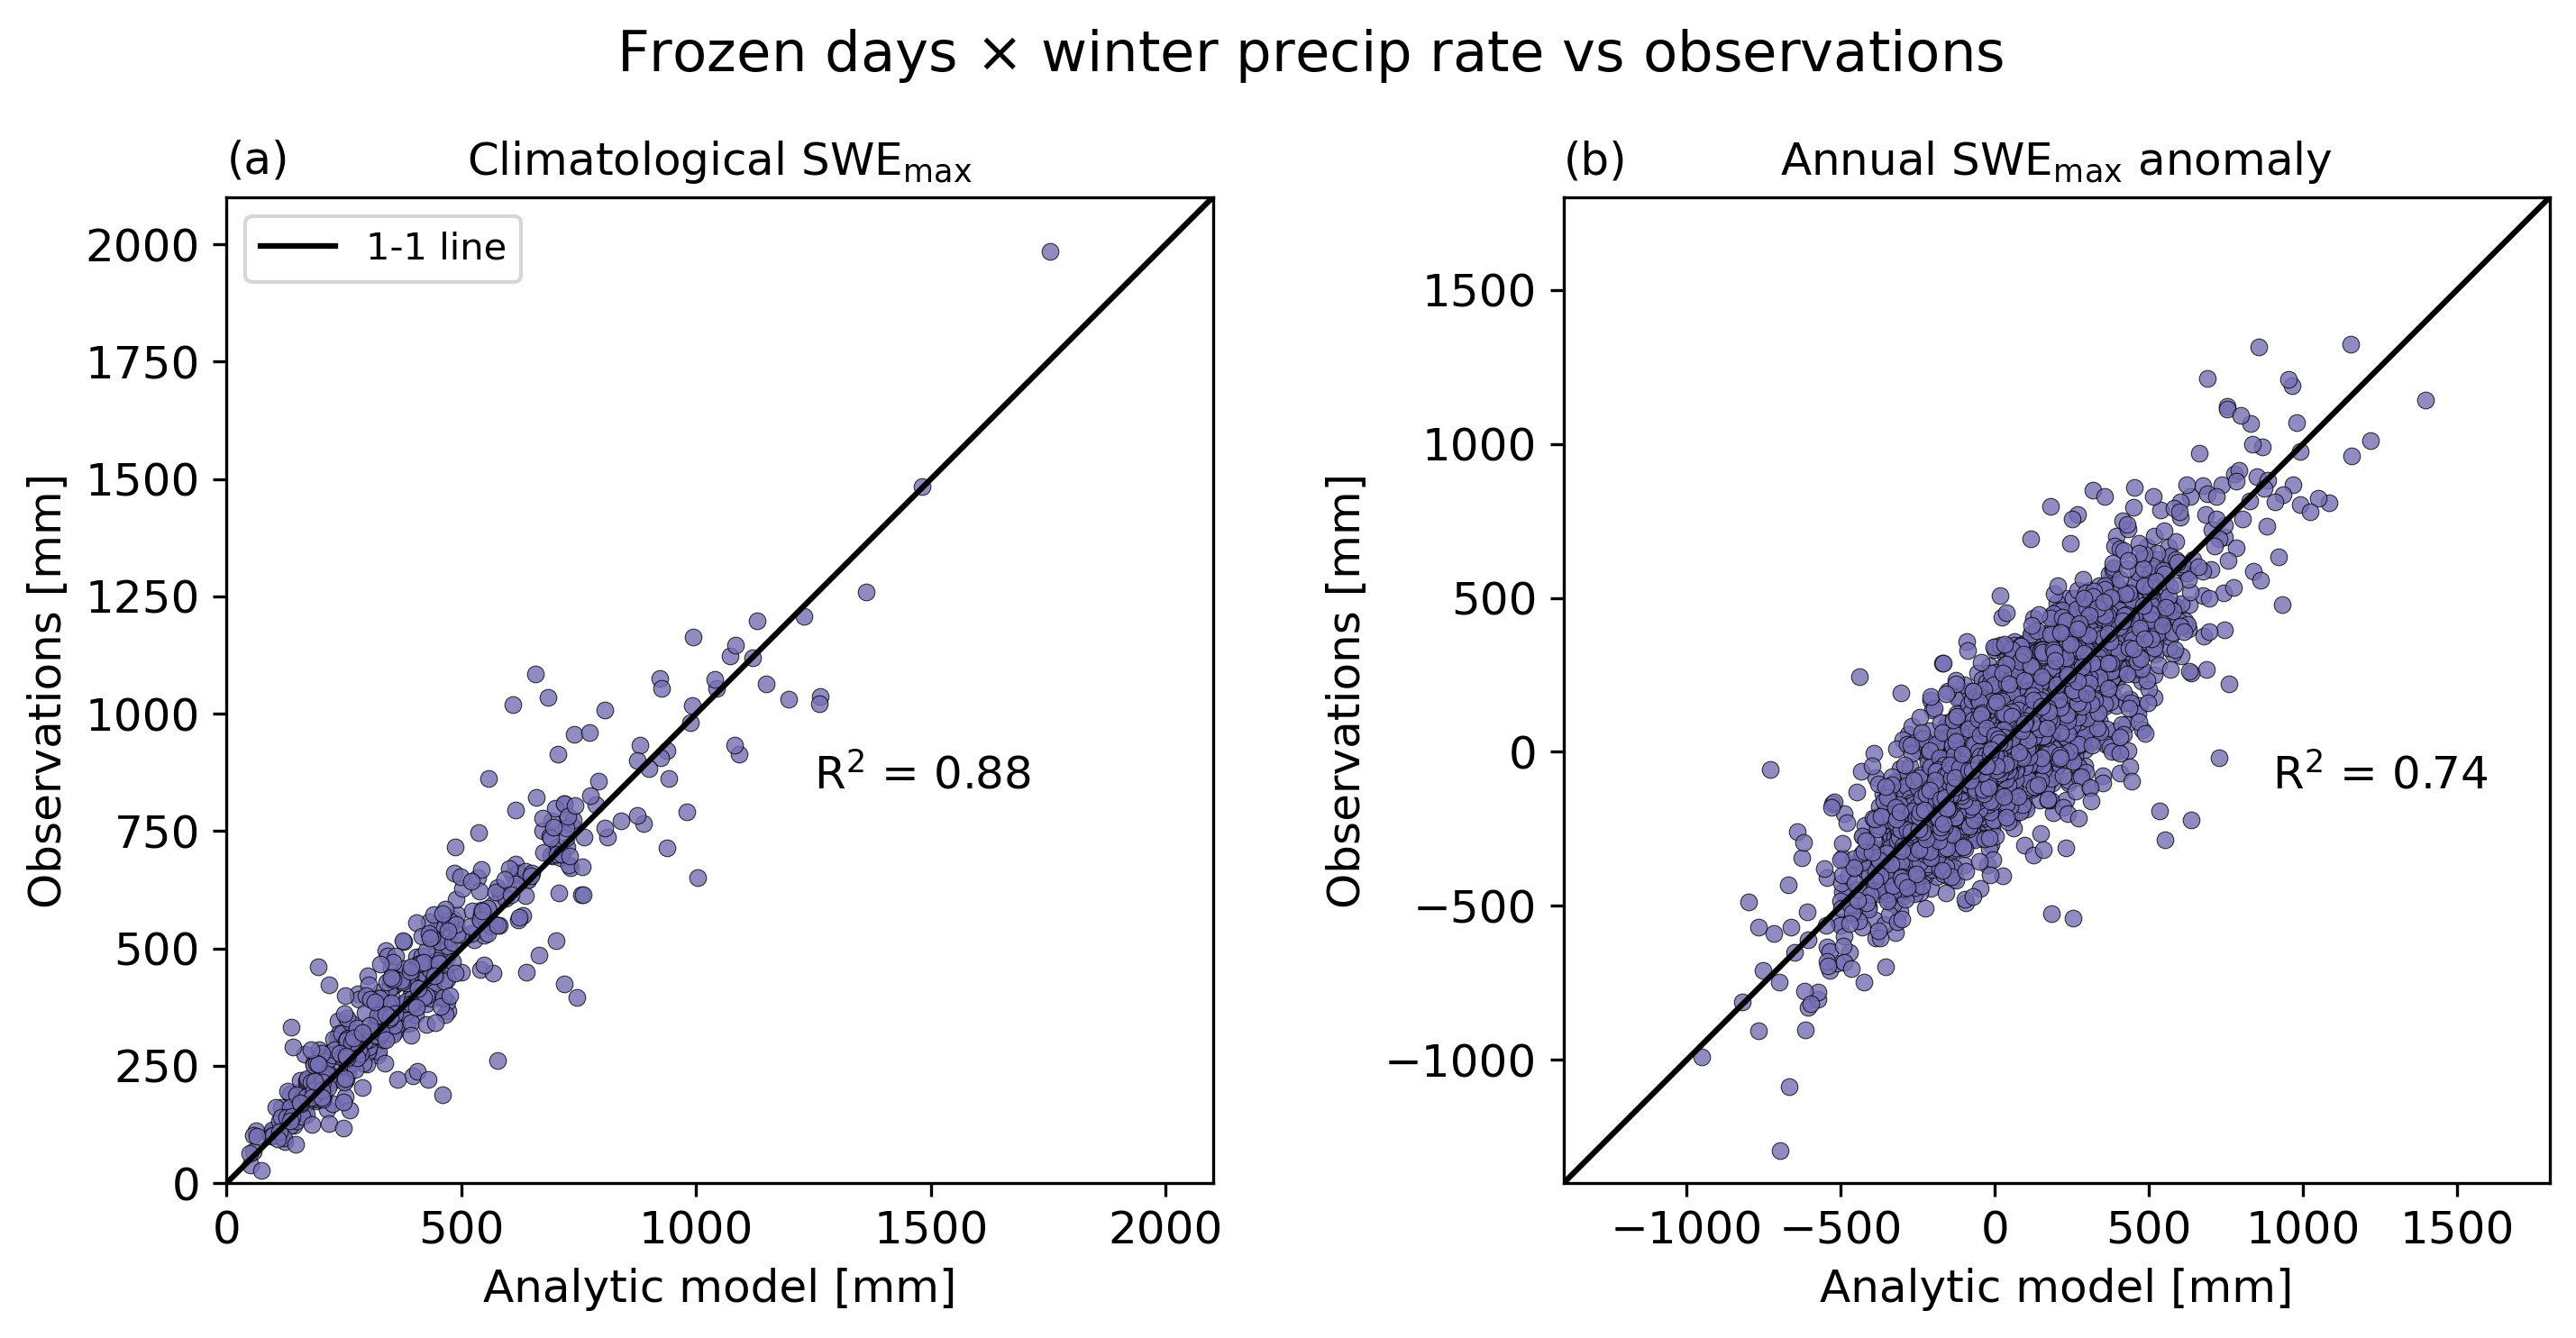

In [11]:
fig = plt.figure(figsize=(10,5),dpi=300)
gs = GridSpec(1,2)

figFontSize = 12

colorTimeDep = '#1b9e77'
colorAnalytic = '#7570b3'
#1b9e77
#d95f02
#7570b3

########################################################

#### Model vs obs climatological max SWE ####
ax0 = fig.add_subplot(gs[0])

xData2 = analyticStation
yData2 = obsStation
thisR2 = round(R2_from1to1(xData2,yData2),2)
ax0.scatter(xData2[0],yData2[0],20,edgecolor='k',linewidth=.25,alpha=.8,c=colorAnalytic)
ax0.scatter(xData2,yData2,20,edgecolor='k',linewidth=.25,alpha=.8,c=colorAnalytic)
ax0.text(1250,840,fr'R$^2$ = {thisR2}',fontsize=figFontSize)

ax0.set_ylabel('Observations [mm]',fontsize=figFontSize)
ax0.set_xlabel('Analytic model [mm]',fontsize=figFontSize)
ax0.axis('square')
ax0.set_xlim([0,2100])
ax0.set_ylim([0,2100])
ax0.set_title(r'Climatological SWE$_\text{max}$',fontsize=figFontSize)

## Plot 1-1 line ##
ax0.plot(np.arange(0,2100),np.arange(0,2100),c='k',label='1-1 line')

ax0.legend(fontsize=figFontSize-2,loc='upper left')

ax0.tick_params(axis='both', labelsize=figFontSize)

ax0.text(0,2150,'(a)',fontsize=figFontSize)

########################################################


#### Model vs obs deviation from climatological max SWE ####
ax1 = fig.add_subplot(gs[1])

xData2 = analyticWY
yData2 = obsWY
thisR2 = round(R2_from1to1(xData2,yData2),2)
ax1.scatter(xData2[0],yData2[0],20,edgecolor='k',linewidth=.25,alpha=.8,c=colorAnalytic)
ax1.scatter(xData2,yData2,20,edgecolor='k',linewidth=.25,alpha=.8,c=colorAnalytic)
ax1.text(900,-120,fr'R$^2$ = {thisR2}',fontsize=figFontSize)

ax1.set_ylabel('Observations [mm]',fontsize=figFontSize)
ax1.set_xlabel(r'Analytic model [mm]',fontsize=figFontSize)
ax1.axis('square')
ax1.set_xlim([-1400,1800])
ax1.set_ylim([-1400,1800])
ax1.set_title(r'Annual SWE$_\text{max}$ anomaly',fontsize=figFontSize)

## Plot 1-1 line ##
ax1.plot(np.arange(-1400,1800),np.arange(-1400,1800),c='k',label='1-1 line')

#ax1.legend(fontsize=figFontSize-2,loc='upper left')

ax1.tick_params(axis='both', labelsize=figFontSize)
ax1.text(-1400,1875,'(b)',fontsize=figFontSize)

fig.suptitle(r'Frozen days $\times$ winter precip rate vs observations',fontsize=15)
fig.subplots_adjust(top=0.75)
plt.tight_layout()

## option to save figure ##
saveFigBool = False
if saveFigBool:
    plt.savefig('...../figure3_AnalyticOnly.pdf')

# Figure 4

PDF of nondimensionalized SWE data. Data computed in sweUniversal.ipynb.

/tmp/ipykernel_180943/1941346194.py:18: RuntimeWarning: divide by zero encountered in log
  c = ax0.contourf(tt,bb,np.log(allHist.T),extend='both',cmap='bone_r',levels=np.arange(-10,-4))
/tmp/ipykernel_180943/1941346194.py:47: RuntimeWarning: divide by zero encountered in log
  c = ax1.contourf(tt,bb,np.log(allHist.T),extend='both',levels=np.arange(-3,3,1),cmap='bone_r')


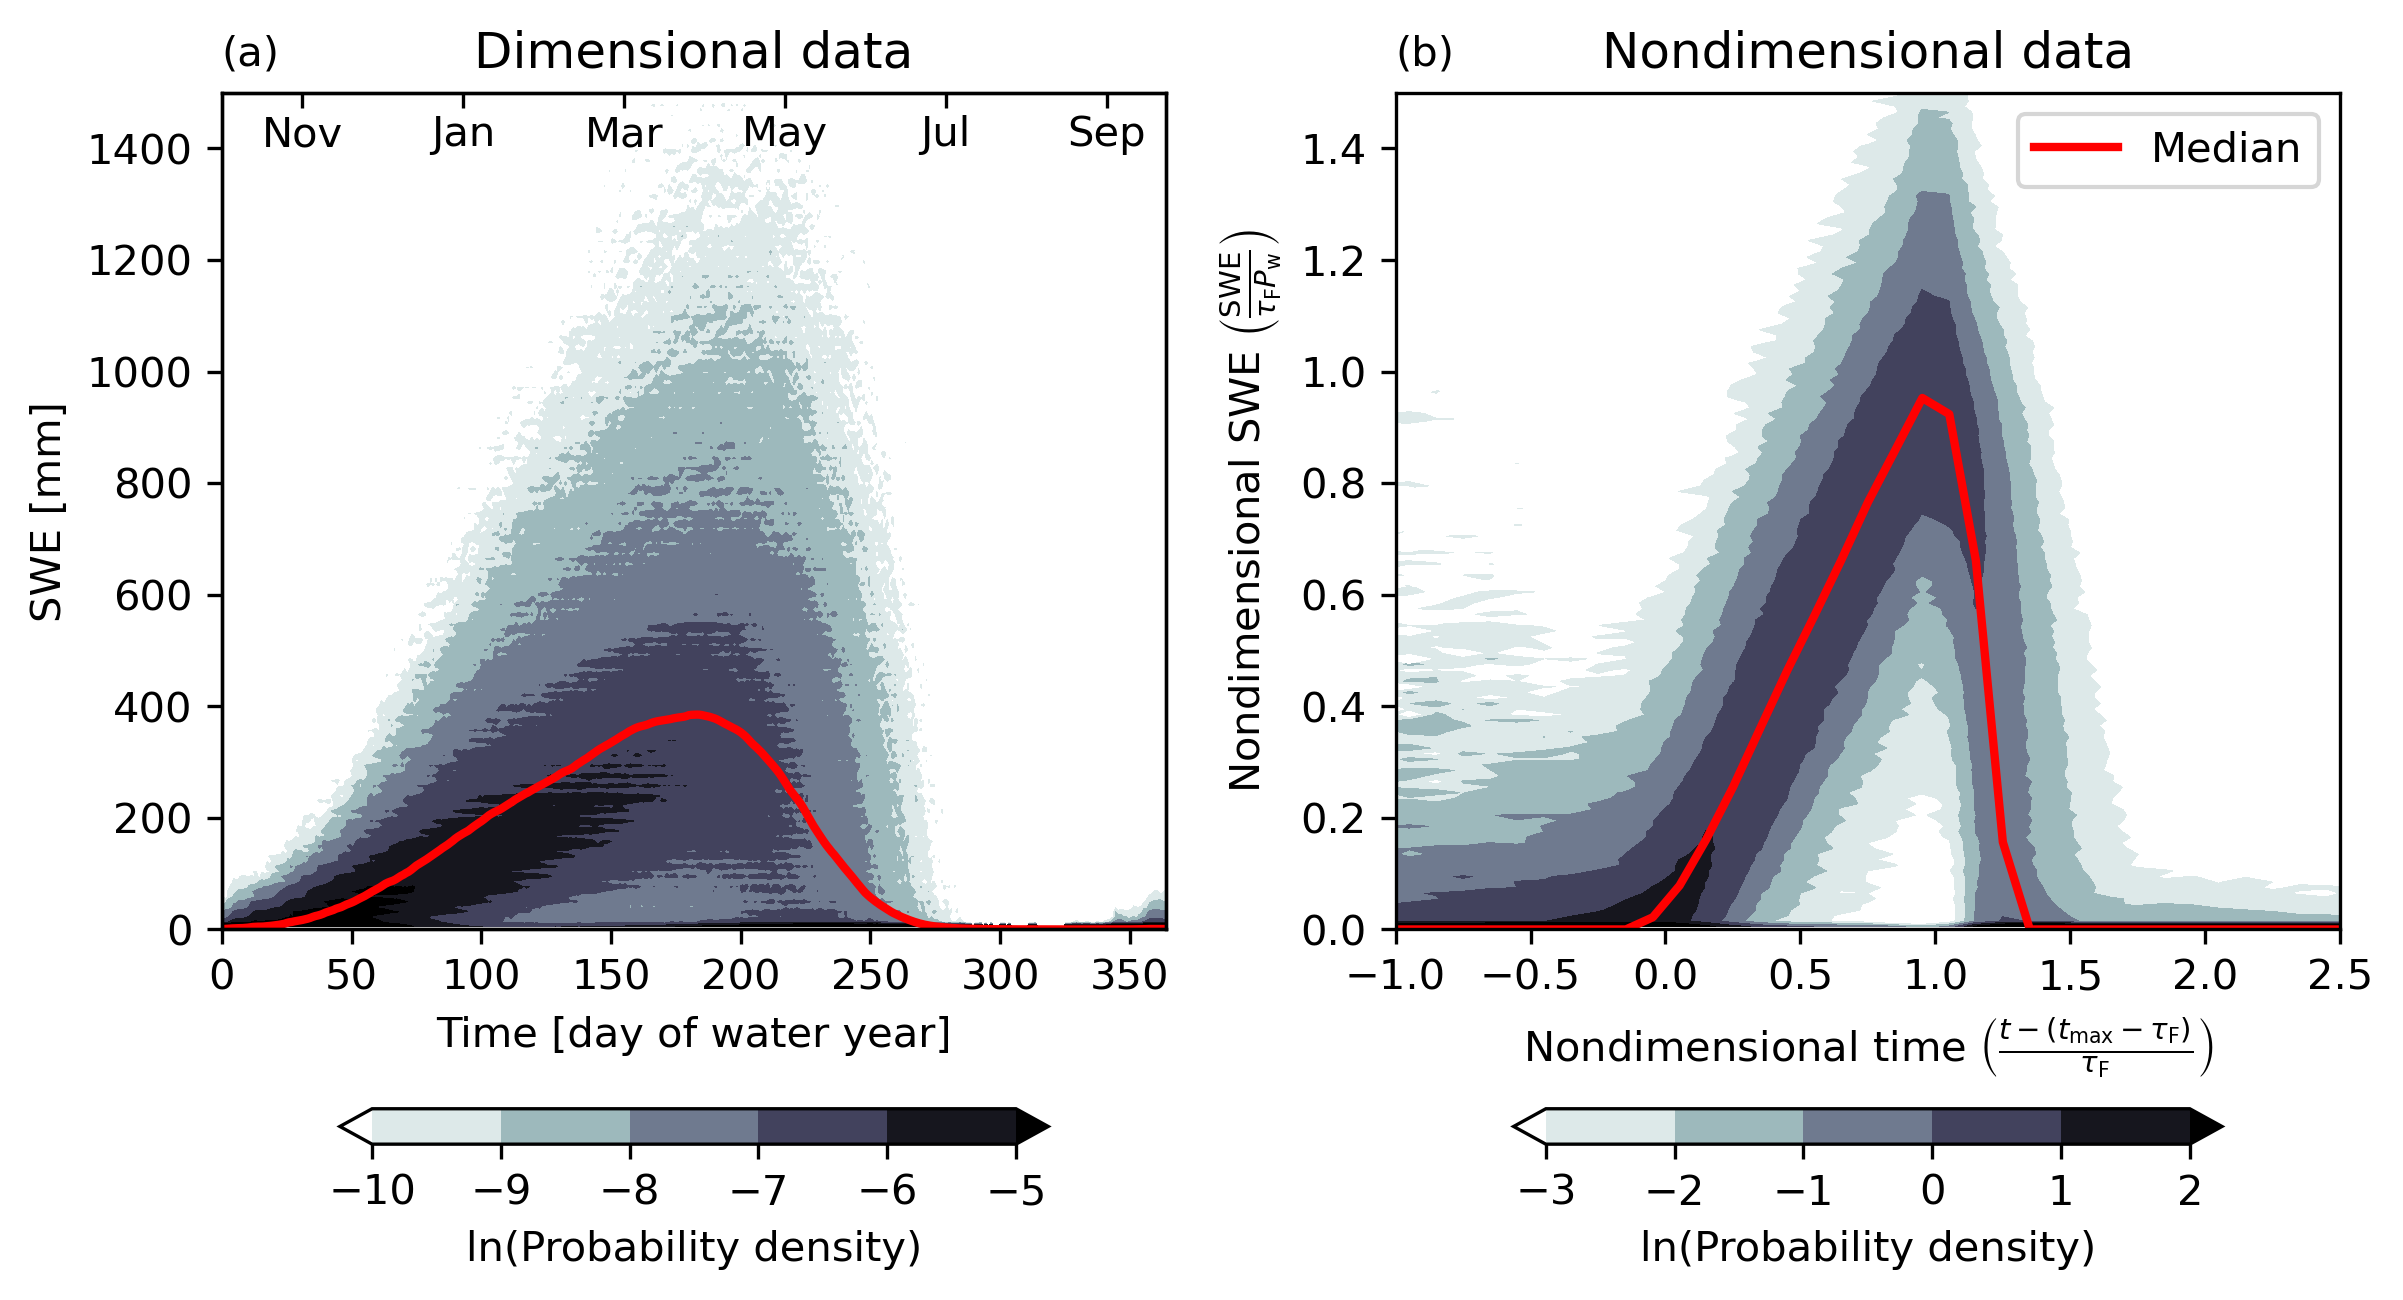

In [12]:
fig, ax = plt.subplots(1,2,figsize=(8,4.5),dpi=300)
ax0 = ax[0]
ax1 = ax[1]

###########################################
# Plot dimensional climatological data #
###########################################

### Load the dimensional SWE timeseries data ###
sweTimeSeriesData = np.load(pathToLoad + '/figure4SWECurvesDim_Water year.npz')
Xmean = sweTimeSeriesData['Xmean']
Ymean = sweTimeSeriesData['Ymean']
tt = sweTimeSeriesData['tt']
bb = sweTimeSeriesData['bb']
allHist = sweTimeSeriesData['allHist']


c = ax0.contourf(tt,bb,np.log(allHist.T),extend='both',cmap='bone_r',levels=np.arange(-10,-4))
plt.colorbar(c,ax=ax0,label='ln(Probability density)',orientation='horizontal',shrink=.75)
ax0.plot(Xmean,Ymean,linewidth=2,c='r',label='Median')
ax0.set_ylabel(r'SWE [mm]')
ax0.set_xlabel('Time [day of water year]')
ax0.set_ylim([0,1500])
ax0.set_xticks(np.arange(0,400,50))
ax0.set_xlim([0,364])

ax2 = ax0.twiny()
ax2.set_xlim([0,364])
ax2.set_xticks(np.arange(0,359,62)+31)
ax2.set_xticklabels(['Nov','Jan','Mar','May','Jul','Sep'],rotation=0);
ax2.tick_params(axis="x",direction="in",pad=-15)
ax0.set_title('Dimensional data')
ax0.text(0,1550,'(a)');

###########################################
# Plot nondimensional climatological data #
###########################################

### Load the nondimensional SWE timeseries data ###
sweTimeSeriesData = np.load(pathToLoad + '/figure4SWECurvesNonDim_Water year.npz')
Xmean = sweTimeSeriesData['Xmean']
Ymean = sweTimeSeriesData['Ymean']
tt = sweTimeSeriesData['tt']
bb = sweTimeSeriesData['bb']
allHist = sweTimeSeriesData['allHist']

c = ax1.contourf(tt,bb,np.log(allHist.T),extend='both',levels=np.arange(-3,3,1),cmap='bone_r')
plt.colorbar(c,ax=ax1,label='ln(Probability density)',orientation='horizontal',shrink=.75)
ax1.plot(Xmean,Ymean,linewidth=2,c='r',label='Median')
ax1.set_xlim([-1,2.5])
ax1.set_ylim([0,1.5])
ax1.legend()
ax1.set_ylabel(r'Nondimensional SWE $\left(\frac{\text{SWE}}{\tau_\text{F}P_\text{w}}\right)$')
ax1.set_xlabel(r'Nondimensional time $\left(\frac{t-(t_\text{max}-\tau_\text{F})}{\tau_\text{F}}\right)$')
ax1.set_title('Nondimensional data')
ax1.text(-1,1.55,'(b)');

plt.tight_layout()

## Save figure
saveBool = 0
if saveBool:
    plt.savefig(f'....../figure_universalSWECurve.pdf')

# Figure 5

Additive sensitivity of $\tau_\text{F}$, $P_\text{w}$, and $S_\text{max}$. Data is computed in Sensitivity.ipynb.

In [13]:
### Load sensitivity data ###
sensitivityData = np.load(pathToLoad + '/figure5AddedSen.npz')

Tw_stationClim = sensitivityData['TwClim']
dlogPw_dTw = sensitivityData['dlogPw_dTw']
dlogTauF_dTw = sensitivityData['dlogTauF_dTw']
dlogSWE_dTw = sensitivityData['dlogSWE_dTw']

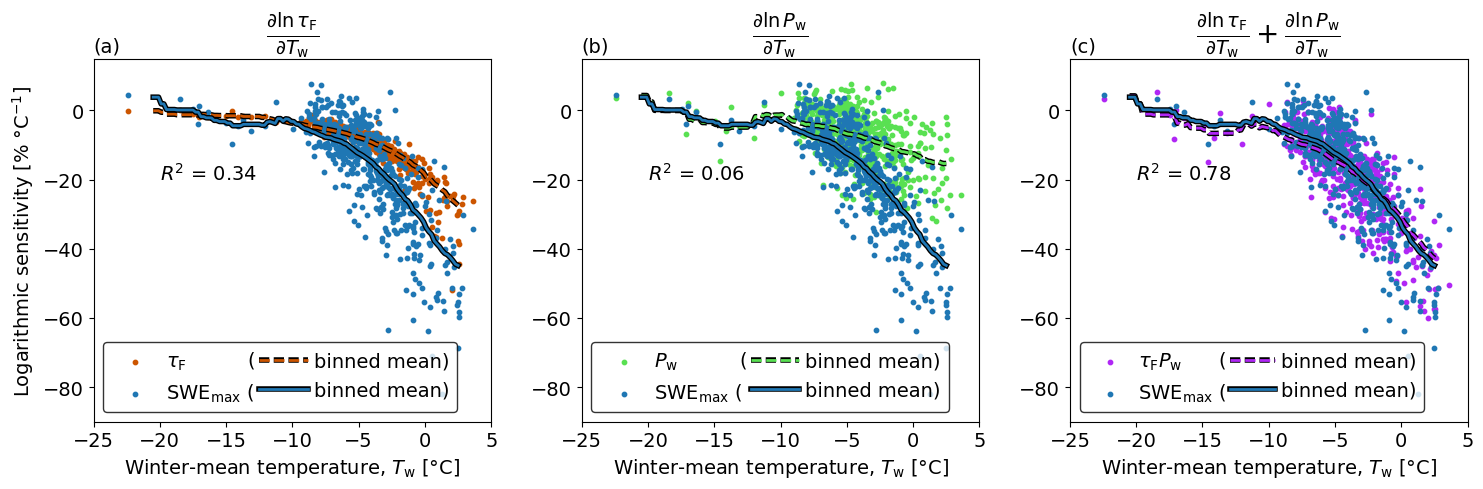

In [14]:
fig,axs = plt.subplots(1,3,figsize=(15,5))

xLabel = r'Winter-mean temperature, $T_\text{w}$ [$\degree$C]'

### Panel 1 ###
rowColor = '#CC5500'
ax1 = axs[0]
xData = Tw_stationClim
yData = dlogTauF_dTw
yData0 = dlogSWE_dTw
ax1.scatter(xData,yData,10,c=rowColor,label=r'$\tau_\text{F}$')
binMidPt,binnedMean = binMeanFunction(yData,xData,5,.2)
ax1.plot(binMidPt,binnedMean,linewidth=2,color=rowColor,linestyle='--',label=r'$\tau_\text{F}$ binned mean',path_effects=[pe.Stroke(linewidth=4, foreground='k'), pe.Normal()])
ax1.scatter(xData,yData0,10,label=r'$\text{SWE}_\text{max}$')
binMidPt,binnedMean = binMeanFunction(yData0,xData,5,.2)
ax1.plot(binMidPt,binnedMean,linewidth=2,linestyle='-',label=r'$\text{SWE}_\text{max}$ binned mean',path_effects=[pe.Stroke(linewidth=4, foreground='k'), pe.Normal()])
ax1.set_ylabel(r'Logarithmic sensitivity [% $\degree$C$^{-1}$]',rotation=90,labelpad=5,fontsize=14)
ax1.set_xlabel(xLabel,fontsize=14)
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.set_ylim([-90,15])
ax1.set_xlim([-25,5])
ax1.set_title(r'$\frac{\partial \ln \tau_\text{F}}{\partial T_\text{w}}$',fontsize=20)
ax1.text(-20,-20,fr'$R^2$ = {round(R2_from1to1(yData,yData0),2)}',fontsize=14)
ax1.text(-25,17,'(a)',fontsize=14)

handles, labels = ax1.get_legend_handles_labels()
handles_ordered_arr = np.array(handles).reshape(2, 2).T
handles_ordered = handles_ordered_arr.flatten()
ax1.legend(handles_ordered, ('$\\tau_\\text{F}$          (', r'$\text{SWE}_\text{max}$ (', 'binned mean)', 'binned mean)'),
          loc='lower left', ncol=2, handlelength=2.5, edgecolor='black',
           handletextpad=0.3, columnspacing=0.2,fontsize=14)

### Panel 2 ###
rowColor = '#59E052'
ax2 = axs[1]
xData = Tw_stationClim
yData = dlogPw_dTw
yData0 = dlogSWE_dTw
ax2.scatter(xData,yData,10,label=r'$P_\text{w}$',c=rowColor)
binMidPt,binnedMean = binMeanFunction(yData,xData,5,.2)
ax2.plot(binMidPt,binnedMean,linewidth=2,color=rowColor,linestyle='--',label=r'$P_\text{w}$ binned mean',path_effects=[pe.Stroke(linewidth=4, foreground='k'), pe.Normal()])
ax2.scatter(xData,yData0,10,label=r'$\text{SWE}_\text{max}$')
binMidPt,binnedMean = binMeanFunction(yData0,xData,5,.2)
ax2.plot(binMidPt,binnedMean,linewidth=2,linestyle='-',label=r'$\text{SWE}_\text{max}$ binned mean',path_effects=[pe.Stroke(linewidth=4, foreground='k'), pe.Normal()])
#ax2.set_ylabel(r'$\frac{\partial \ln x}{\partial T_\text{w}}$ [% K$^{-1}$]',rotation=90,labelpad=5,fontsize=20)
ax2.set_xlabel(xLabel,fontsize=14)
ax2.tick_params(axis='both', which='major', labelsize=14)
ax2.set_ylim([-90,15])
ax2.set_xlim([-25,5])
ax2.set_title(r'$\frac{\partial \ln P_\text{w}}{\partial T_\text{w}}$',fontsize=20)
ax2.text(-20,-20,fr'$R^2$ = {round(R2_from1to1(yData,yData0),2)}',fontsize=14)
ax2.text(-25,17,'(b)',fontsize=14)

handles, labels = ax2.get_legend_handles_labels()
handles_ordered_arr = np.array(handles).reshape(2, 2).T
handles_ordered = handles_ordered_arr.flatten()
ax2.legend(handles_ordered, ('$P_\\text{w}$          (', r'$\text{SWE}_\text{max}$ (', 'binned mean)', 'binned mean)'),
          loc='lower left', ncol=2, handlelength=2.5, edgecolor='black',
           handletextpad=0.3, columnspacing=0.2,fontsize=14)


### Panel 3 ###
rowColor = '#B027F5'
ax3 = axs[2]
xData = Tw_stationClim
yData = (dlogPw_dTw+dlogTauF_dTw)
yData0 = dlogSWE_dTw
ax3.scatter(xData,yData,10,label=r'$\tau_\text{F} P_\text{w}$',c=rowColor)
binMidPt,binnedMean = binMeanFunction(yData,xData,5,.2)
ax3.plot(binMidPt,binnedMean,linewidth=2,color=rowColor,linestyle='--',label=r'binned mean',path_effects=[pe.Stroke(linewidth=4, foreground='k'), pe.Normal()])
ax3.scatter(xData,yData0,10,label=r'$\text{SWE}_\text{max}$')
binMidPt,binnedMean = binMeanFunction(yData0,xData,5,.2)
ax3.plot(binMidPt,binnedMean,linewidth=2,linestyle='-',label=r'$\text{SWE}_\text{max}$ binned mean',path_effects=[pe.Stroke(linewidth=4, foreground='k'), pe.Normal()])
#ax3.set_ylabel(r'$\frac{\partial \ln x}{\partial T_\text{w}}$ [% K$^{-1}$]',rotation=90,labelpad=5,fontsize=20)
ax3.set_xlabel(xLabel,fontsize=14)
ax3.tick_params(axis='both', which='major', labelsize=14)
ax3.set_ylim([-90,15])
ax3.set_xlim([-25,5])
ax3.set_title(r'$\frac{\partial \ln \tau_\text{F}}{\partial T_\text{w}} + \frac{\partial \ln P_\text{w}}{\partial T_\text{w}}$',fontsize=20)
ax3.text(-20,-20,fr'$R^2$ = {round(R2_from1to1(yData,yData0),2)}',fontsize=14)
ax3.text(-25,17,'(c)',fontsize=14)

handles, labels = ax3.get_legend_handles_labels()
handles_ordered_arr = np.array(handles).reshape(2, 2).T
handles_ordered = handles_ordered_arr.flatten()
ax3.legend(handles_ordered, (r'$\tau_\text{F}P_\text{w}$      (', r'$\text{SWE}_\text{max}$ (', 'binned mean)', 'binned mean)'),
          loc='lower left', ncol=2, handlelength=2.3, edgecolor='black',
           handletextpad=0.3, columnspacing=0.2,fontsize=14)

plt.tight_layout()

saveFigBool = 0
if saveFigBool:
    plt.savefig('...../figure5_analyticSenBreakdown.pdf')

# Figure 6
WY 2026 plots. Data is computed in waterYear2025_2026.ipynb.

In [19]:
### Load data ###
wy26Data = np.load(pathToLoad + '/figure6_wy26.npz',allow_pickle=True)

wy26PercentNoRecord = wy26Data['wy26PercentNoRecord']
noRecordLats = wy26Data['noRecordLats']
noRecordLons = wy26Data['noRecordLons']
wy26PercentRecord = wy26Data['wy26PercentRecord']
recordLons = wy26Data['recordLons']
recordLats = wy26Data['recordLats']
allStateDict_2526 = wy26Data['allStateDict_2526'].item()
climSWE_T_DICT = wy26Data['climSWE_T_DICT'].item()
PwClimArray = wy26Data['PwClimArray']
tauFClimArray = wy26Data['tauFClimArray']
tauF2526Array = wy26Data['tauF2526Array']
Pw2526Array = wy26Data['Pw2526Array']
SWEmax2526Array = wy26Data['SWEmax2526Array']
stationNumbers = wy26Data['stationNumbers']
sweMaxPercentOfNormal = wy26Data['sweMaxPercentOfNormal']
stationStates = wy26Data['stationStates']


stateNames = ['CO','AK','AZ','CA','ID','MT','NM','NV','OR','SD','UT','WA','WY']

In [20]:
# create indices for shifting data to start on Oct 1
daysToAnalyze = np.arange(1,367)
dates = np.array([datetime.datetime(2000, 1, 1) + datetime.timedelta(int(d) - 1) for d in daysToAnalyze])
months = np.array([d.month for d in dates])
waterYearInds = np.append(np.nonzero(months>=10)[0],np.nonzero(months<10)[0])
waterYearInds = waterYearInds[waterYearInds<365]

In [21]:
stationNumber = 709

In [22]:
## Generate climatology for plot ##
stationClimSWE = stationLookupByNumber(stationNumber,climSWE_T_DICT)

climTime = np.arange(365)#stationClimSWE.dayofyear.values[waterYearInds]
climSWECycle = stationClimSWE.values[waterYearInds]
sweMaxCycle = stationClimSWE.sweMax.values[waterYearInds]
sweMinCycle = stationClimSWE.sweMin.values[waterYearInds]
climPw = PwClimArray[stationNumbers==stationNumber]
climTauF = tauFClimArray[stationNumbers==stationNumber]
climSWECycleMaxDay = np.argmax(climSWECycle)
clim_pwDomain = np.arange(climSWECycleMaxDay-climTauF,climSWECycleMaxDay)

## And data for the specific station ##
chosenStation = stationLookupByNumber(stationNumber,allStateDict_2526)
wy2526SWE = chosenStation.swe.values
wy2526Time = np.arange(len(wy2526SWE))
wy2526TauFDays = np.nonzero(chosenStation.T_avg.values<0)[0]
wy2526PeakSWEDay = np.argmax(wy2526SWE)
wy2526TauF = len(wy2526TauFDays)
wy2526Pw = chosenStation.Pw
wy2526_pwDomain = np.arange(wy2526PeakSWEDay-wy2526TauF,wy2526PeakSWEDay)

/tmp/ipykernel_180943/2102875510.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  clim_pwDomain = np.arange(climSWECycleMaxDay-climTauF,climSWECycleMaxDay)


/tmp/ipykernel_180943/2271571343.py:189: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


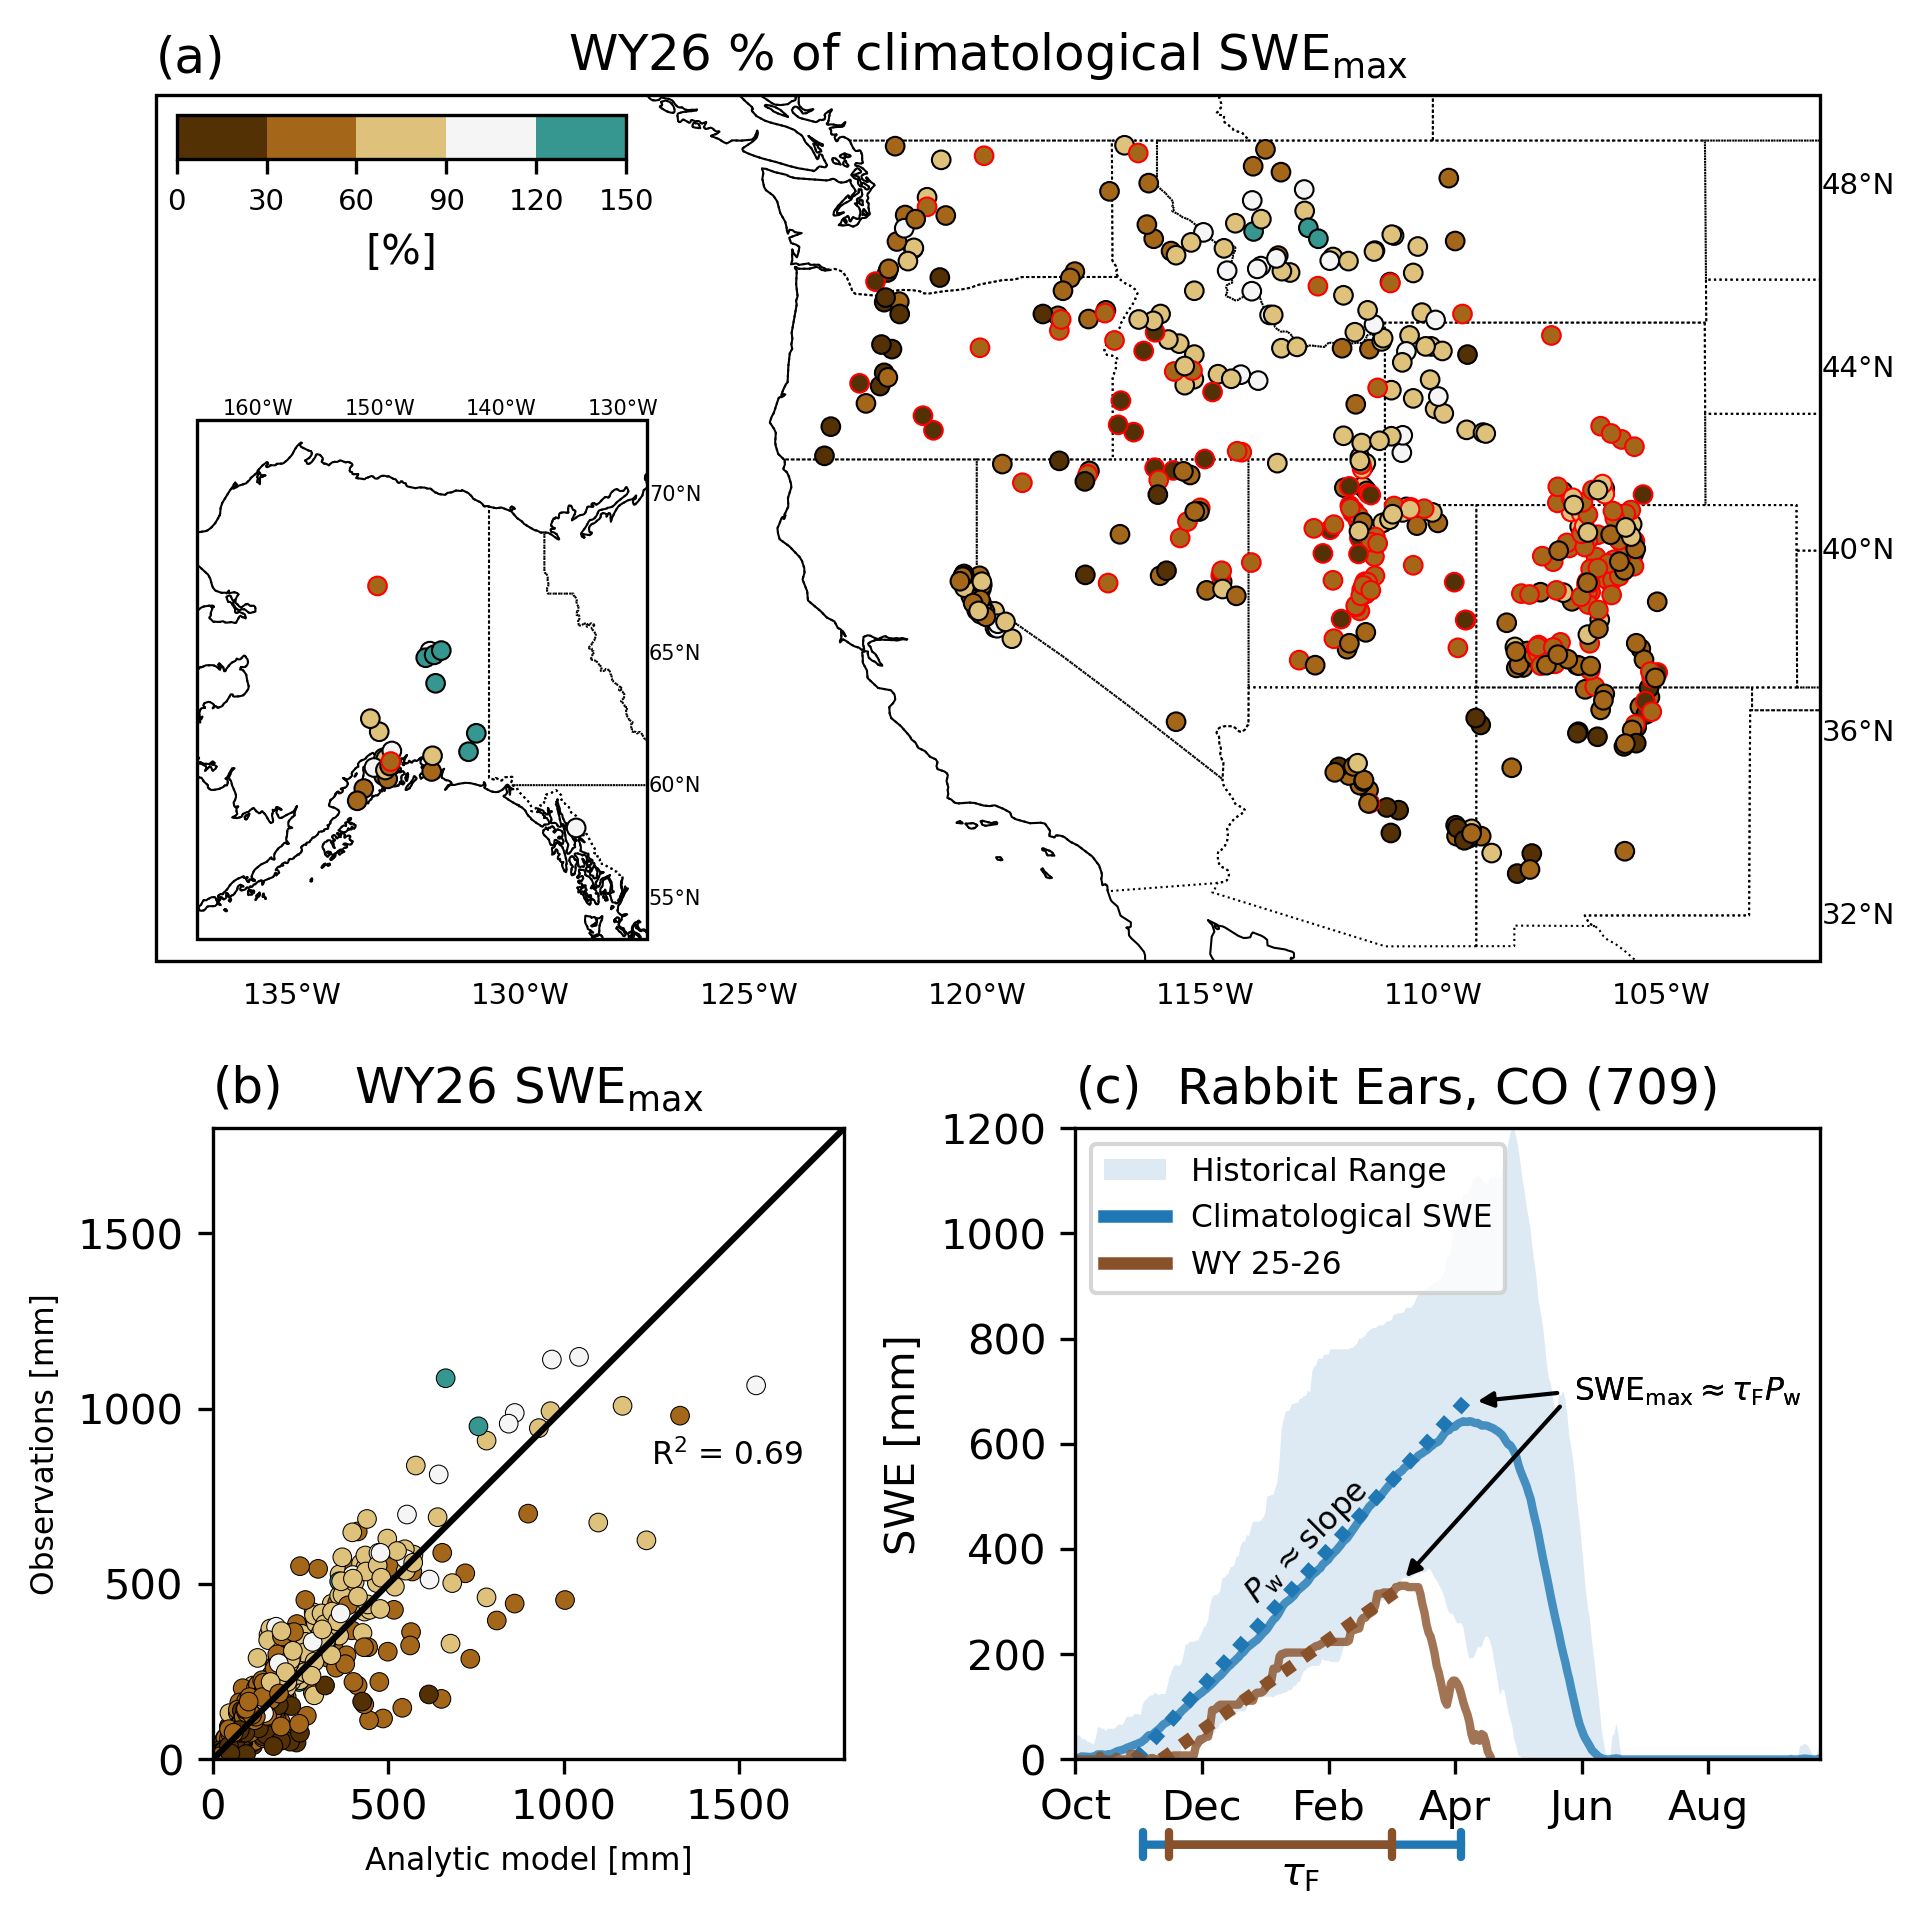

In [23]:
fig = plt.figure(figsize=(6.5,6.5),dpi=300)
gs = GridSpec(2,2,width_ratios=[1,1],height_ratios=[1,.7])
annoFontSize = 7.5

########################################
  ########## Map ###############
########################################

# Continental US Stations #
ax = fig.add_subplot(gs[0,:], projection=ccrs.PlateCarree())


# Add coastlines
ax.coastlines(linewidth=0.5,zorder=-1)

# Add U.S. state borders
ax.add_feature(cfeature.STATES, linestyle=':', edgecolor='black', linewidth=0.5,zorder=-1)
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True)
gl.xlines = False
gl.ylines = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.top_labels = False
gl.left_labels = False
gl.ylocator = mticker.FixedLocator(np.arange(32,54,4))
gl.xlabel_style = {'size': 7, 'color': 'k', 'va':'top'}
gl.ylabel_style = {'size': 7, 'color': 'k', 'ha':'right'}

scatterSize = 20
    
# define the bins and normalize
cmap = shiftedColorMap2('BrBG',midpoint=2/3,stop=0.8)
bounds = np.arange(0,170,30)
norm = matplotlib.colors.BoundaryNorm(bounds, cmap.N)

# plot some of the non-record breaking stations
shuffle1 = np.arange(len(wy26PercentNoRecord))
np.random.shuffle(shuffle1)
shuffled1 = wy26PercentNoRecord[shuffle1]
shuffled1Lats = noRecordLats[shuffle1]
shuffled1Lons = noRecordLons[shuffle1]
sc = ax.scatter(shuffled1Lons[:200],shuffled1Lats[:200],scatterSize,
                 c=shuffled1[:200],cmap=cmap,edgecolor='k',linewidth=.5,zorder=0,norm=norm)

# Plot record breaking stations
sc = ax.scatter(recordLons,recordLats,20,
                c=wy26PercentRecord,edgecolor='r',linewidth=.5,zorder=0,norm=norm,cmap = cmap)

# plot the rest of the stations
sc = ax.scatter(shuffled1Lons[200:],shuffled1Lats[200:],20,
                 c=shuffled1[200:],edgecolor='k',linewidth=.5,zorder=0,norm=norm,cmap = cmap)
    
#### Alaska stations ####
axins = ax.inset_axes(bounds = [-.14,0.025,0.6,.6],projection=ccrs.Mercator())
axins.scatter(noRecordLons,noRecordLats,scatterSize,
              c=wy26PercentNoRecord,cmap=cmap,edgecolor='k',linewidth=.5,transform=ccrs.PlateCarree(),zorder=0,norm=norm)
axins.scatter(recordLons,recordLats,20,
                c=wy26PercentRecord,edgecolor='r',linewidth=.5,transform=ccrs.PlateCarree(),zorder=0,norm=norm,cmap = cmap)
axins.coastlines(linewidth=0.5,zorder=-1)
axins.add_feature(cfeature.STATES, linestyle=':', edgecolor='black', linewidth=0.5,zorder=-1)
lon1, lon2, lat1, lat2 = -165, -128, 53, 72
axins.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
gl = axins.gridlines(crs=ccrs.PlateCarree(), draw_labels=True)
gl.xlines = False
gl.ylines = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.bottom_labels = False
gl.left_labels = False
gl.ylocator = mticker.FixedLocator(np.arange(55,75,5))
gl.xlabel_style = {'size': 5, 'color': 'k', 'va':'top'}
gl.ylabel_style = {'size': 5, 'color': 'k', 'ha':'right'}


# add colorbar
cbaxes = inset_axes(ax,
    width="27%",  # width: 50% of parent_bbox width
    height="5%",  # height: 5%
    loc="upper left",
)
cbaxes.xaxis.set_ticks_position("bottom")
cbar = fig.colorbar(sc,cax=cbaxes,label=r'[%]',
            orientation='horizontal')
cbar.ax.tick_params(labelsize=7)

ax.set_title(r'WY26 % of climatological SWE$_\text{max}$',fontsize=12)

lon1, lon2, lat1, lat2 = -138, -101.5, 31, 50
ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())

ax.text(-138,50.5,'(a)',fontsize=12)


########################################
  ########## R^2 plot ###############
########################################
panelFontSize = 7.5
ax1 = fig.add_subplot(gs[1,0])

ax1.scatter(tauF2526Array*Pw2526Array,SWEmax2526Array,20,c=sweMaxPercentOfNormal,
            edgecolor='k',linewidth=.25,cmap=cmap,norm=norm)
ax1.plot(np.arange(0,1800),np.arange(0,1800),c='k',label='1-1 line')

ax1.set_xlim([0,2100])
ax1.set_ylim([0,2100])

thisR2 = round(R2_from1to1(tauF2526Array*Pw2526Array,SWEmax2526Array),2)
ax1.text(1250,840,fr'R$^2$ = {thisR2}',fontsize=panelFontSize)

ax1.set_ylabel('Observations [mm]',fontsize=panelFontSize)
ax1.set_xlabel('Analytic model [mm]',fontsize=panelFontSize)
ax1.axis('square')
ax1.set_xlim([0,1800])
ax1.set_ylim([0,1800])
ax1.set_title(r'WY26 SWE$_\text{max}$',fontsize=12)
ax1.text(0,1875,'(b)',fontsize=12)


########################################
  ########## Station Demo ###############
########################################

#### Plot of seasonal cycle ####
ax1 = fig.add_subplot(gs[1,1])
backgroundColor = 'tab:blue'#'#808080'

ax1.fill_between(climTime,sweMinCycle,sweMaxCycle,alpha=.15,facecolor=backgroundColor,label='Historical Range')
ax1.plot(climTime,climSWECycle,linewidth=2,c=backgroundColor,alpha=.8)
ax1.plot(np.arange(0,0),np.arange(0,0),c=backgroundColor,linestyle='-',linewidth=3,label='Climatological SWE')

ax1.plot(clim_pwDomain,np.arange(len(clim_pwDomain))*climPw,c=backgroundColor,linestyle=(0, (1, 1)),linewidth=3)

center = ((climSWECycleMaxDay-climTauF)[0],0)
p1 = (climSWECycleMaxDay,0)
p2 = (climSWECycleMaxDay,max(np.arange(len(clim_pwDomain))*climPw))

trans = ax1.get_xaxis_transform()
plt.annotate("", xytext=(climSWECycleMaxDay-climTauF, -.135), xy=(climSWECycleMaxDay, -.135),xycoords=trans,
           arrowprops=dict(arrowstyle="|-|",edgecolor=backgroundColor,linewidth=2,mutation_scale=3))


#### WY Plot 25-26 ####
brownColor = '#895129'
chosenStation = stationLookupByNumber(stationNumber,allStateDict_2526)
ax1.plot(wy2526Time,wy2526SWE,linewidth=2,alpha=.8,c=brownColor)
ax1.plot(np.arange(0,0),np.arange(0,0),linestyle='-',linewidth=3,label='WY 25-26',c=brownColor)

ax1.plot(wy2526_pwDomain,np.arange(len(wy2526_pwDomain))*wy2526Pw,linestyle=(0, (1, 1)),c=brownColor,linewidth=3)
trans = ax1.get_xaxis_transform()
ax1.annotate("", xytext=(wy2526PeakSWEDay-wy2526TauF, -.135), xy=(wy2526PeakSWEDay, -.135),xycoords=trans,
           arrowprops=dict(arrowstyle="|-|",edgecolor=brownColor,linewidth=2,mutation_scale=3,linestyle='-'))
ax1.text(100,-240,r'$\tau_\text{F}$',fontsize=annoFontSize+2)

center = (wy2526PeakSWEDay-wy2526TauF,0)
p1 = (wy2526PeakSWEDay,0)
p2 = (wy2526PeakSWEDay,max(np.arange(len(wy2526_pwDomain))*wy2526Pw))

ax1.legend(fontsize=7.5)
ax1.set_ylim([0,1200])
ax1.set_xlim([0,365])
ax1.set_xticks(np.arange(0,359,62))
ax1.set_ylabel('SWE [mm]')
ax1.set_xticklabels(['Oct','Dec','Feb','Apr','Jun','Aug'],rotation=0);

ann = ax1.annotate(r'$\text{SWE}_\text{max} \approx \tau_\text{F} P_\text{w}$',
                  xy=(climSWECycleMaxDay, climTauF*climPw-10), xycoords='data',
                  xytext=(300,700), textcoords='data',
                  size=annoFontSize, va="center", ha="center",
                  #bbox=dict(boxstyle="round4", fc="w"),
                  arrowprops=dict(arrowstyle="-|>",
                                  #connectionstyle="arc3,rad=0.2",
                                  relpos=(0., .5),
                                  fc="k"))

ann = ax1.annotate(r"$\text{SWE}_\text{max} \approx \tau_\text{F} P_\text{w}$",
                  xy=(wy2526PeakSWEDay, wy2526TauF*wy2526Pw+10), xycoords='data',
                  xytext=(300,700), textcoords='data',
                  size=annoFontSize, va="center", ha="center",
                  #bbox=dict(boxstyle="round4", fc="w"),
                  arrowprops=dict(arrowstyle="-|>",
                                  relpos=(0,.5),
                                  fc="k"))

ax1.text(80,300,r'$P_\text{w}\approx$slope',rotation=45,fontsize=annoFontSize)#90-np.atan((climTauF*climPw)/climSWECycleMaxDay)[0]*180/np.pi)

ax1.set_title('Rabbit Ears, CO (709)',fontsize=12)
ax1.text(0,1250,'(c)',fontsize=12)

plt.tight_layout()


saveFigBool = 0
if saveFigBool:
    plt.savefig(f'...../figure6_wy26.pdf')

# Figure 7

Behavior and sensitivity of $\tau_\text{F}$ with applied uniform warming. Data is computed in T0overT1.ipynb and sineWave.ipynb.

In [26]:
### Load \tau_F sensitvity data ###
tauFSenData = np.load(pathToLoad + '/figure7Sen.npz')

TwArray = tauFSenData['TwArray']
Tw_adjs = tauFSenData['Tw_adjs']
odrBestFitFunction = np.poly1d(tauFSenData['odrBestFitFunction'])
adjTauFList = tauFSenData['adjTauFList']
tauFSenList_EtauF = tauFSenData['tauFSenList_EtauF']
stationApproxAmpsSin = tauFSenData['stationApproxAmpsSin']


### Load temperature data ###
    # from sineWave.ipynb
tempData = np.load(pathToLoad + '/figure7Dist.npz')

winterInds = tempData['winterInds']
winterTemps = tempData['winterTemps']
compTemps = tempData['compTemps']
allTemps = tempData['allTemps']

groupedByDay = []
for i in range(365):
    specDayOfYear = []
    for j in range(36):
        specDayOfYear = specDayOfYear + [allTemps[i+j*365]]
    groupedByDay = groupedByDay + [specDayOfYear]

meanSeasonalCycle = np.array([np.nanmean(np.array(day)) for day in groupedByDay])
stdDevSeasonalCycle = np.array([np.nanstd(np.array(day)) for day in groupedByDay])

/tmp/ipykernel_180943/3515475240.py:33: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  annualMeanTemp_i = Tw[i] - (1/(260-109))*np.trapz(T_prime)
/tmp/ipykernel_180943/873301316.py:107: RuntimeWarning: invalid value encountered in arccos
  tauF_0sigma = 2/omega * np.arccos(annualMean_fromTw(TwRange,a)/a)
/tmp/ipykernel_180943/873301316.py:148: RuntimeWarning: invalid value encountered in arccos
  tauF_0sigma = 2/omega * np.arccos(T0overT1Range_fullDeterm)
/tmp/ipykernel_180943/873301316.py:149: RuntimeWarning: invalid value encountered in sqrt
  analyticDeriv_0sigma = -2/(omega*12)*(1/np.sqrt(1-T0overT1Range_fullDeterm**2))/tauF_0sigma
/tmp/ipykernel_180943/873301316.py:149: RuntimeWarning: divide by zero encountered in divide
  analyticDeriv_0sigma = -2/(omega*12)*(1/np.sqrt(1-T0overT1Range_fullDeterm**2))/tauF_0sigma
/tmp/ipykernel_180943/3515475240.py:12: DeprecationWarning: `trapz` is depreca

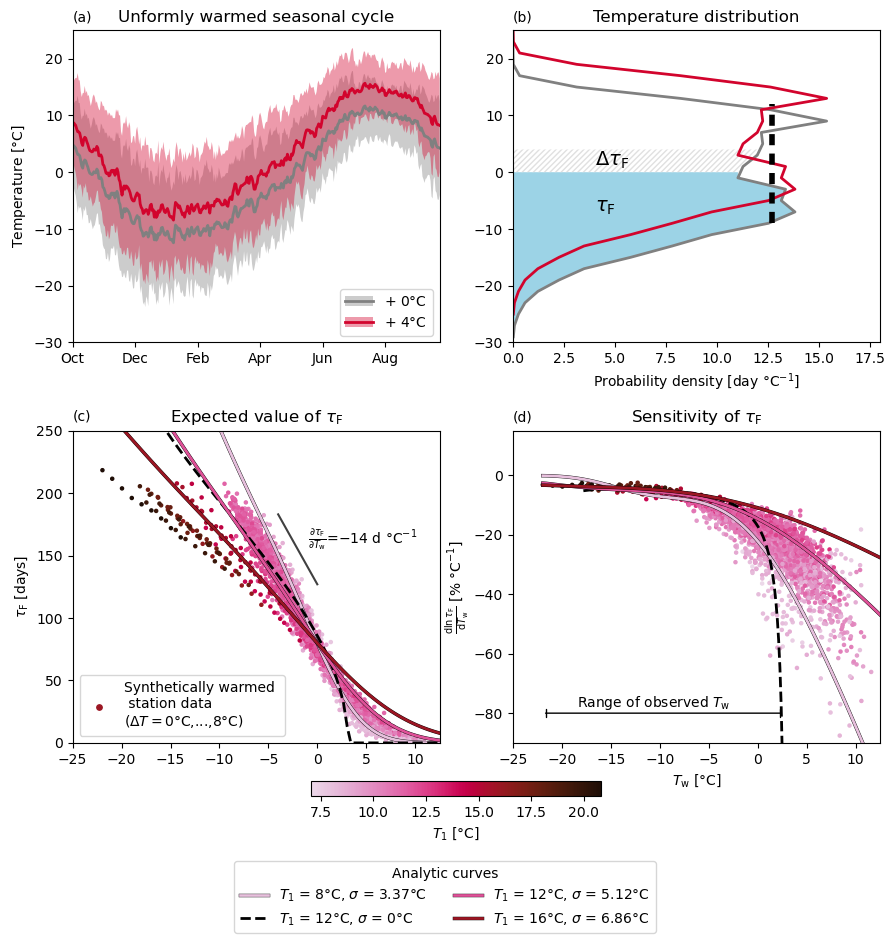

In [27]:
fig = plt.figure(figsize=(9,9))

gs = GridSpec(2,1)

topRow = gs[0].subgridspec(1,2,width_ratios=[1, 1])
bottomRow = gs[1].subgridspec(1,2)

                                    ########################
                                        ### Schematic ###
                                    ########################

#### Plot of seasonal cycle ####
ax0 = fig.add_subplot(topRow[0])

origSeasonalCycle = meanSeasonalCycle
origSTD = stdDevSeasonalCycle
origColor = '#808080'

ts = ax0.plot(origSeasonalCycle,linewidth=2,c=origColor)
ax0.fill_between(np.arange(365),origSeasonalCycle-2*origSTD,origSeasonalCycle+2*origSTD,alpha=.4,facecolor=origColor)
box = ax0.fill(np.nan, np.nan, alpha=0.4,facecolor=origColor) # for legend entry

warmingLevel = 4
warmColor = '#D2042D'
warmerSeasonalCycle = origSeasonalCycle + warmingLevel
tsW = ax0.plot(warmerSeasonalCycle,c=warmColor,linewidth=2)
ax0.fill_between(np.arange(365),warmerSeasonalCycle-2*origSTD,
                 warmerSeasonalCycle+2*origSTD,alpha=.4,facecolor=warmColor)
boxW = ax0.fill(np.nan, np.nan, warmColor, alpha=0.4) # for legend entry
ax0.legend([(box[0], ts[0]),(boxW[0], tsW[0])],
           [fr'+ {0}$\degree$C',fr'+ {warmingLevel}$\degree$C'])
ax0.set_ylim((-30,25))

ax0.set_ylabel(r'Temperature [$\degree$C]')

ax0.set_xlim([0,364])
ax0.set_xticks(np.arange(0,359,62))
ax0.set_xticklabels(['Oct','Dec','Feb','Apr','Jun','Aug'],rotation=0)
ax0.text(0,26.5,'(a)')
title = ax0.set_title('Unformly warmed seasonal cycle')

#### Plot distributions ####
ax1 = fig.add_subplot(topRow[1])

bins = np.arange(-30,27,2)
pdf,binEdges = np.histogram(allTemps[~np.isnan(allTemps)], bins, density=True)
binCenters = (binEdges[:-1]+binEdges[1:])/2
ax1.plot(pdf*365,binCenters,linewidth=2,label=r'+ {0}$\degree$C',c=origColor)
zeroLine = np.zeros(binCenters.size)
ax1.fill_between(pdf*365,zeroLine,binCenters,alpha=.4,where=(zeroLine > binCenters),facecolor='#0992C2')

allTempsWarmer = allTemps + warmingLevel
ax1.plot(pdf*365,binCenters+4,linewidth=2,label=fr'+ {warmingLevel}$\degree$C',c=warmColor)

warmLine = np.ones(binCenters.size)*warmingLevel
domainMod = copy.deepcopy(binCenters)
domainMod[binCenters<0] = 0
ax1.fill_between(pdf*365,warmLine,domainMod,alpha=1,where=(warmLine > domainMod),
                 facecolor='none',linewidth=0,hatch='//////',edgecolor='#e0e0e0')

ax1.text(4,1.2,r'$\Delta\tau_\text{F}$',zorder=1,fontsize=14)

ax1.text(4,-7,r'$\tau_\text{F}$',zorder=1,fontsize=14)

flatStart = -9
flatEnd = 12
flDomain = np.arange(flatStart,flatEnd+1)
ax1.plot(np.ones(flDomain.shape)*np.mean(pdf[np.logical_and(binCenters>flatStart,binCenters<flatEnd)])*365,
         flDomain,
        c='k',linestyle=(0, (2, 1.5)),linewidth=4)
ax1.set_xlabel('Probability density [day $\degree$C$^{-1}$]')
ax1.set_title('Temperature distribution')
ax1.set_ylim((-30,25))
ax1.set_xlim((0,18))
ax1.text(0,26.5,'(b)')

# ax1.annotate(r'Area of blue shading = $\tau_\text{F}$', xy=(5, -5), xytext=(10, -20),
#             arrowprops=dict(facecolor='black', shrink=0.05),
#             )

################################################
        ### Numerical Experiments ###
################################################

### Colormap selection ###
normalize = Normalize(vmin=np.min(stationApproxAmpsSin), vmax=np.max(stationApproxAmpsSin))
scalarMap = ScalarMappable(norm=normalize, cmap=cmr.get_sub_cmap('cmr.flamingo_r', 0.1, 0.9))

####################################

#### Plot of tau_F ####
ax0 = fig.add_subplot(bottomRow[0])

### Add analytic curves ###
amplitudeRange = np.array([8,12,16])
TwRange = np.linspace(np.min(TwArray),15,100) 

# compute sigma based on best fit between sigma and T1 in obs
sigma_fromBestFit = odrBestFitFunction(amplitudeRange)

## add determinsitic curve ##
omega = 2*np.pi/365

## add noisy curves ##
for ja,a in enumerate(amplitudeRange):
    if ja==1: # plot deterministic curve now
        tauF_0sigma = 2/omega * np.arccos(annualMean_fromTw(TwRange,a)/a)
        tauF_0sigma[np.logical_and(np.isnan(tauF_0sigma),TwRange>-10)]=0
        ax0.plot(TwRange,tauF_0sigma,linewidth=2,
                 linestyle='--',c='k')#,label=r'$T_1$ = 12$\degree$C, $\sigma$ = 0$\degree$C')
    T0Range = annualMean_fromTw(TwRange,a) # assumes cosine seasonal cycle to map Tw to T0
    ax0.plot(TwRange,E_tauF_normalDistDaily(a,sigma_fromBestFit[ja],T0Range),linewidth=2,
             c=scalarMap.to_rgba(a),
            path_effects=[pe.Stroke(linewidth=2.5, foreground='k'), pe.Normal()])
            # label=r'$T_1$ = ' + f'{a}' + r'$\degree$C, $\sigma$ = '+f'{round(sigma_fromBestFit[ja],2)}' + r'$\degree$C'

## add station data ##
for l,adj in enumerate(Tw_adjs):
    ax0.scatter(TwArray[l],adjTauFList[l],5,c=stationApproxAmpsSin,cmap=scalarMap.cmap)

# for legend
ax0.scatter(TwArray[0]-100,adjTauFList[0],15,color=scalarMap.to_rgba(16),
            label='Synthetically warmed \n station data \n' + r'($\Delta T = 0\degree$C,...,8$\degree$C)')

## add demo slope to show linearity of tau_F##
demoRange = np.linspace(-2,2,30)
ax0.plot(demoRange-2,-14*(demoRange)+155,c='k',alpha=.75)
ax0.text(-1,160,r'$\frac{\partial\tau_\text{F}}{\partial T_\text{w}}$=$-$14 d $\degree$C$^{-1}$',fontsize=10)

ax0.set_ylim(0,250);
ax0.set_xlim([-25,12.5])
ax0.set_ylabel(r'$\tau_\text{F}$ [days]')

ax0.legend(loc='lower left')

ax0.set_title(r'Expected value of $\tau_\text{F}$')

ax0.text(-25,258,'(c)')

#### Plot of tau_F sensitivity ####
ax1 = fig.add_subplot(bottomRow[1])

### Add analytic curves ###

## add determinsitic curve ##
T0overT1Range_fullDeterm = np.linspace(-.75,2.5,300)
omega = 2*np.pi/365
tauF_0sigma = 2/omega * np.arccos(T0overT1Range_fullDeterm)
analyticDeriv_0sigma = -2/(omega*12)*(1/np.sqrt(1-T0overT1Range_fullDeterm**2))/tauF_0sigma

## add noisy curves ##
for ja,a in enumerate(amplitudeRange):
    if ja==1: # plot deterministic curve now
        ax1.plot(Tw_fromCos(T0overT1Range_fullDeterm*a,a),analyticDeriv_0sigma*100,linewidth=2,linestyle='--',
        c='k',label=r'$T_1$ = 12$\degree$C, $\sigma$ = 0$\degree$C')
    T0Range = annualMean_fromTw(TwRange,a) # assumes cosine seasonal cycle
    analyticDeriv = (np.gradient(np.log(E_tauF_normalDistDaily(a,sigma_fromBestFit[ja],T0Range)))/(np.gradient(TwRange)))
    ax1.plot(TwRange,analyticDeriv*100,linewidth=2,
             label=r'$T_1$ = ' + f'{a}' + r'$\degree$C, $\sigma$ = '+f'{round(sigma_fromBestFit[ja],2)}' + r'$\degree$C',
             c=scalarMap.to_rgba(a),
            path_effects=[pe.Stroke(linewidth=2.5, foreground='k'), pe.Normal()])

## add station data ##
for l,adj in enumerate(Tw_adjs):
    colorbarPlot = ax1.scatter(TwArray[l],tauFSenList_EtauF[l]*100,5,c=stationApproxAmpsSin,cmap=scalarMap.cmap)

cbar = fig.colorbar(colorbarPlot,ax=[ax0,ax1],shrink = .6,orientation='horizontal',fraction=0.046, pad=0.04)
cbar.ax.set_xlabel(r'$T_1$ [$\degree$C]')

ax1.set_ylim([-90,15])
ax1.set_xlim([-25,12.5])

ax1.set_ylabel(r'$\frac{\text{d}\ln \tau_\text{F}}{\text{d}T_\text{w}}$' + ' [% $\degree$C$^{-1}$]',rotation=90,labelpad=2)
ax1.set_xlabel(r'$T_\text{w}$ [$\degree$C]')

### one legend for both plots ###
lines_labels = [ax1.get_legend_handles_labels()]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]

ax1.legend(lines, labels, loc = 'lower center', bbox_to_anchor = (0, -0.05, 1, 1),
           bbox_transform = plt.gcf().transFigure,ncol=2,title='Analytic curves')

## add arrow showing modern station data ##
q_end, q_start = np.percentile(TwArray[0], [100 ,0])
ax1.annotate("", xytext=(q_start, -80), xy=(q_end-1, -80),
                arrowprops=dict(arrowstyle="|-|",edgecolor='k',linewidth=1,mutation_scale=3))
ax1.text(-18.5,-78,r'Range of observed $T_\text{w}$',fontsize=10)

ax1.set_title(r'Sensitivity of $\tau_\text{F}$')
ax1.text(-25,18,'(d)')

plt.tight_layout()

saveFigBool = 0
if saveFigBool:
    plt.savefig('..../figure7_tauFChanges4Panel.pdf',bbox_inches='tight')

# Figure A1: $P_\text{w}$ vs $P_{\tau_\text{F}}$

Plot the precipitation rate averaged during the winter ($P_\text{w}$) against that averaged on days with $T<0$  ($P_{\tau_\text{F}}$). Calculated in modelHeirarchy.ipynb.

In [28]:
### Load data ###
pData = np.load(pathToLoad + '/figureA1_PwPtauF.npz',allow_pickle=True)

pTauFAll = pData['pTauFAll']
pwAll = pData['pwAll']
pTauFMean = pData['pTauFMean']
pwMean = pData['pwMean']

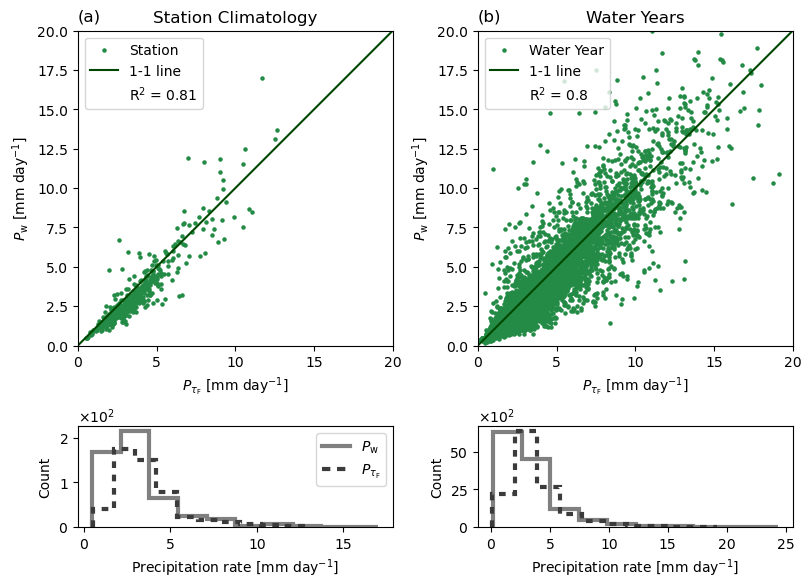

In [29]:
### Plot ###
supTitleFontSize = 16
titleFontSize = 12
fig, axs = plt.subplot_mosaic([['scatMean', 'scatAll'],
                               ['histMean', 'histAll']],
                              figsize=(8, 6),
                              width_ratios=(1, 1), height_ratios=(4, 1),
                              layout='constrained')


#### Mean across years ####
ax0 = axs['scatMean']
ax0.scatter(pTauFMean,pwMean,5,label='Station',c = '#238b45')#8A9A5B  ba3c3c
ax0.set_ylabel(r'$P_\text{w}$ [mm day$^{-1}$]')
ax0.set_xlabel(r'$P_{\tau_\text{F}}$ [mm day$^{-1}$]')
ax0.axis('square')
ax0.set_xlim([0,20])
ax0.set_ylim([0,20])

## Plot 1-1 line ##
ax0.plot(np.arange(-50,50),np.arange(-50,50),c='#004700',label='1-1 line')
thisR2 = R2_from1to1(pTauFMean,pwMean)
ax0.plot([], [], ' ', label=fr'R$^2$ = {round(thisR2,2)}')

ax0.legend()
ax0.set_title('Station Climatology',fontsize=titleFontSize)
ax0.text(0,20.6,'(a)',fontsize=titleFontSize)

#### Histogram for the climatology ####
ax01 = axs['histMean']
ax01.hist(pwMean,histtype='step',linewidth=3,label=r'$P_\text{w}$',color='#808080')
ax01.hist(pTauFMean,histtype='step',linewidth=3,label=r'$P_{\tau_\text{F}}$',linestyle=(0, (1.6, 1.6)),color='#3B3B3B')
ax01.ticklabel_format(axis='y',scilimits=(2,2),useMathText=True)
ax01.set_ylabel('Count')
ax01.set_xlabel('Precipitation rate [mm day$^{-1}$]')
handles, labels = ax01.get_legend_handles_labels()
leg_entries = {}
for h, label in zip(handles, labels):
    if label==r'$P_{\tau_\text{F}}$':
        linestyle = (0, (2, 1.6))
    else:
        linestyle = 'solid'
    leg_entries[label] = Line2D([0], [0], color=h.get_facecolor()[:-1],
                                alpha=h.get_alpha(), lw=h.get_linewidth(), linestyle = linestyle)
labels_sorted, lines = zip(*sorted(leg_entries.items()))
ax01.legend(lines, labels_sorted)

#### Showing all years ####
ax1 = axs['scatAll']
ax1.scatter(pTauFAll,pwAll,5,c='#238b45',label='Water Year')
ax1.set_ylabel(r'$P_\text{w}$ [mm day$^{-1}$]')
ax1.set_xlabel(r'$P_{\tau_\text{F}}$ [mm day$^{-1}$]')
ax1.axis('square')
ax1.set_xlim([0,20])
ax1.set_ylim([0,20])

## Plot 1-1 line ##
ax1.plot(np.arange(-1100,1800),np.arange(-1100,1800),c='#004700',label='1-1 line')
thisR2 = R2_from1to1(pTauFAll,pwAll)
ax1.plot([], [], ' ', label=fr'R$^2$ = {round(thisR2,2)}')

ax1.legend(loc='upper left')
ax1.set_title('Water Years',fontsize=titleFontSize)
ax1.text(0,20.6,'(b)',fontsize=titleFontSize)

#### Histogram for individual years ####
ax11 = axs['histAll']
ax11.hist(pwAll,histtype='step',linewidth=3,color='#808080')
ax11.hist(pTauFAll,histtype='step',linewidth=3,color='#3B3B3B',linestyle=(0, (1.6, 1.6)))
ax11.ticklabel_format(axis='y',scilimits=(2,2),useMathText=True)
ax11.set_ylabel('Count')
ax11.set_xlabel('Precipitation rate [mm day$^{-1}$]')


saveFigBool = 0
if saveFigBool:
    plt.savefig('...../figureA1_PwPtauF.pdf',bbox_inches='tight')

# Figure C1

Example plots from WY 26. Uses the same data as Fig 6.

/tmp/ipykernel_180943/1495356719.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  clim_pwDomain = np.arange(climSWECycleMaxDay-climTauF,climSWECycleMaxDay)
/tmp/ipykernel_180943/1495356719.py:117: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  clim_pwDomain = np.arange(climSWECycleMaxDay-climTauF,climSWECycleMaxDay)
/tmp/ipykernel_180943/1495356719.py:188: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  clim_pwDomain = np.arange(climSWECycleMaxDay-climTauF,climSWE

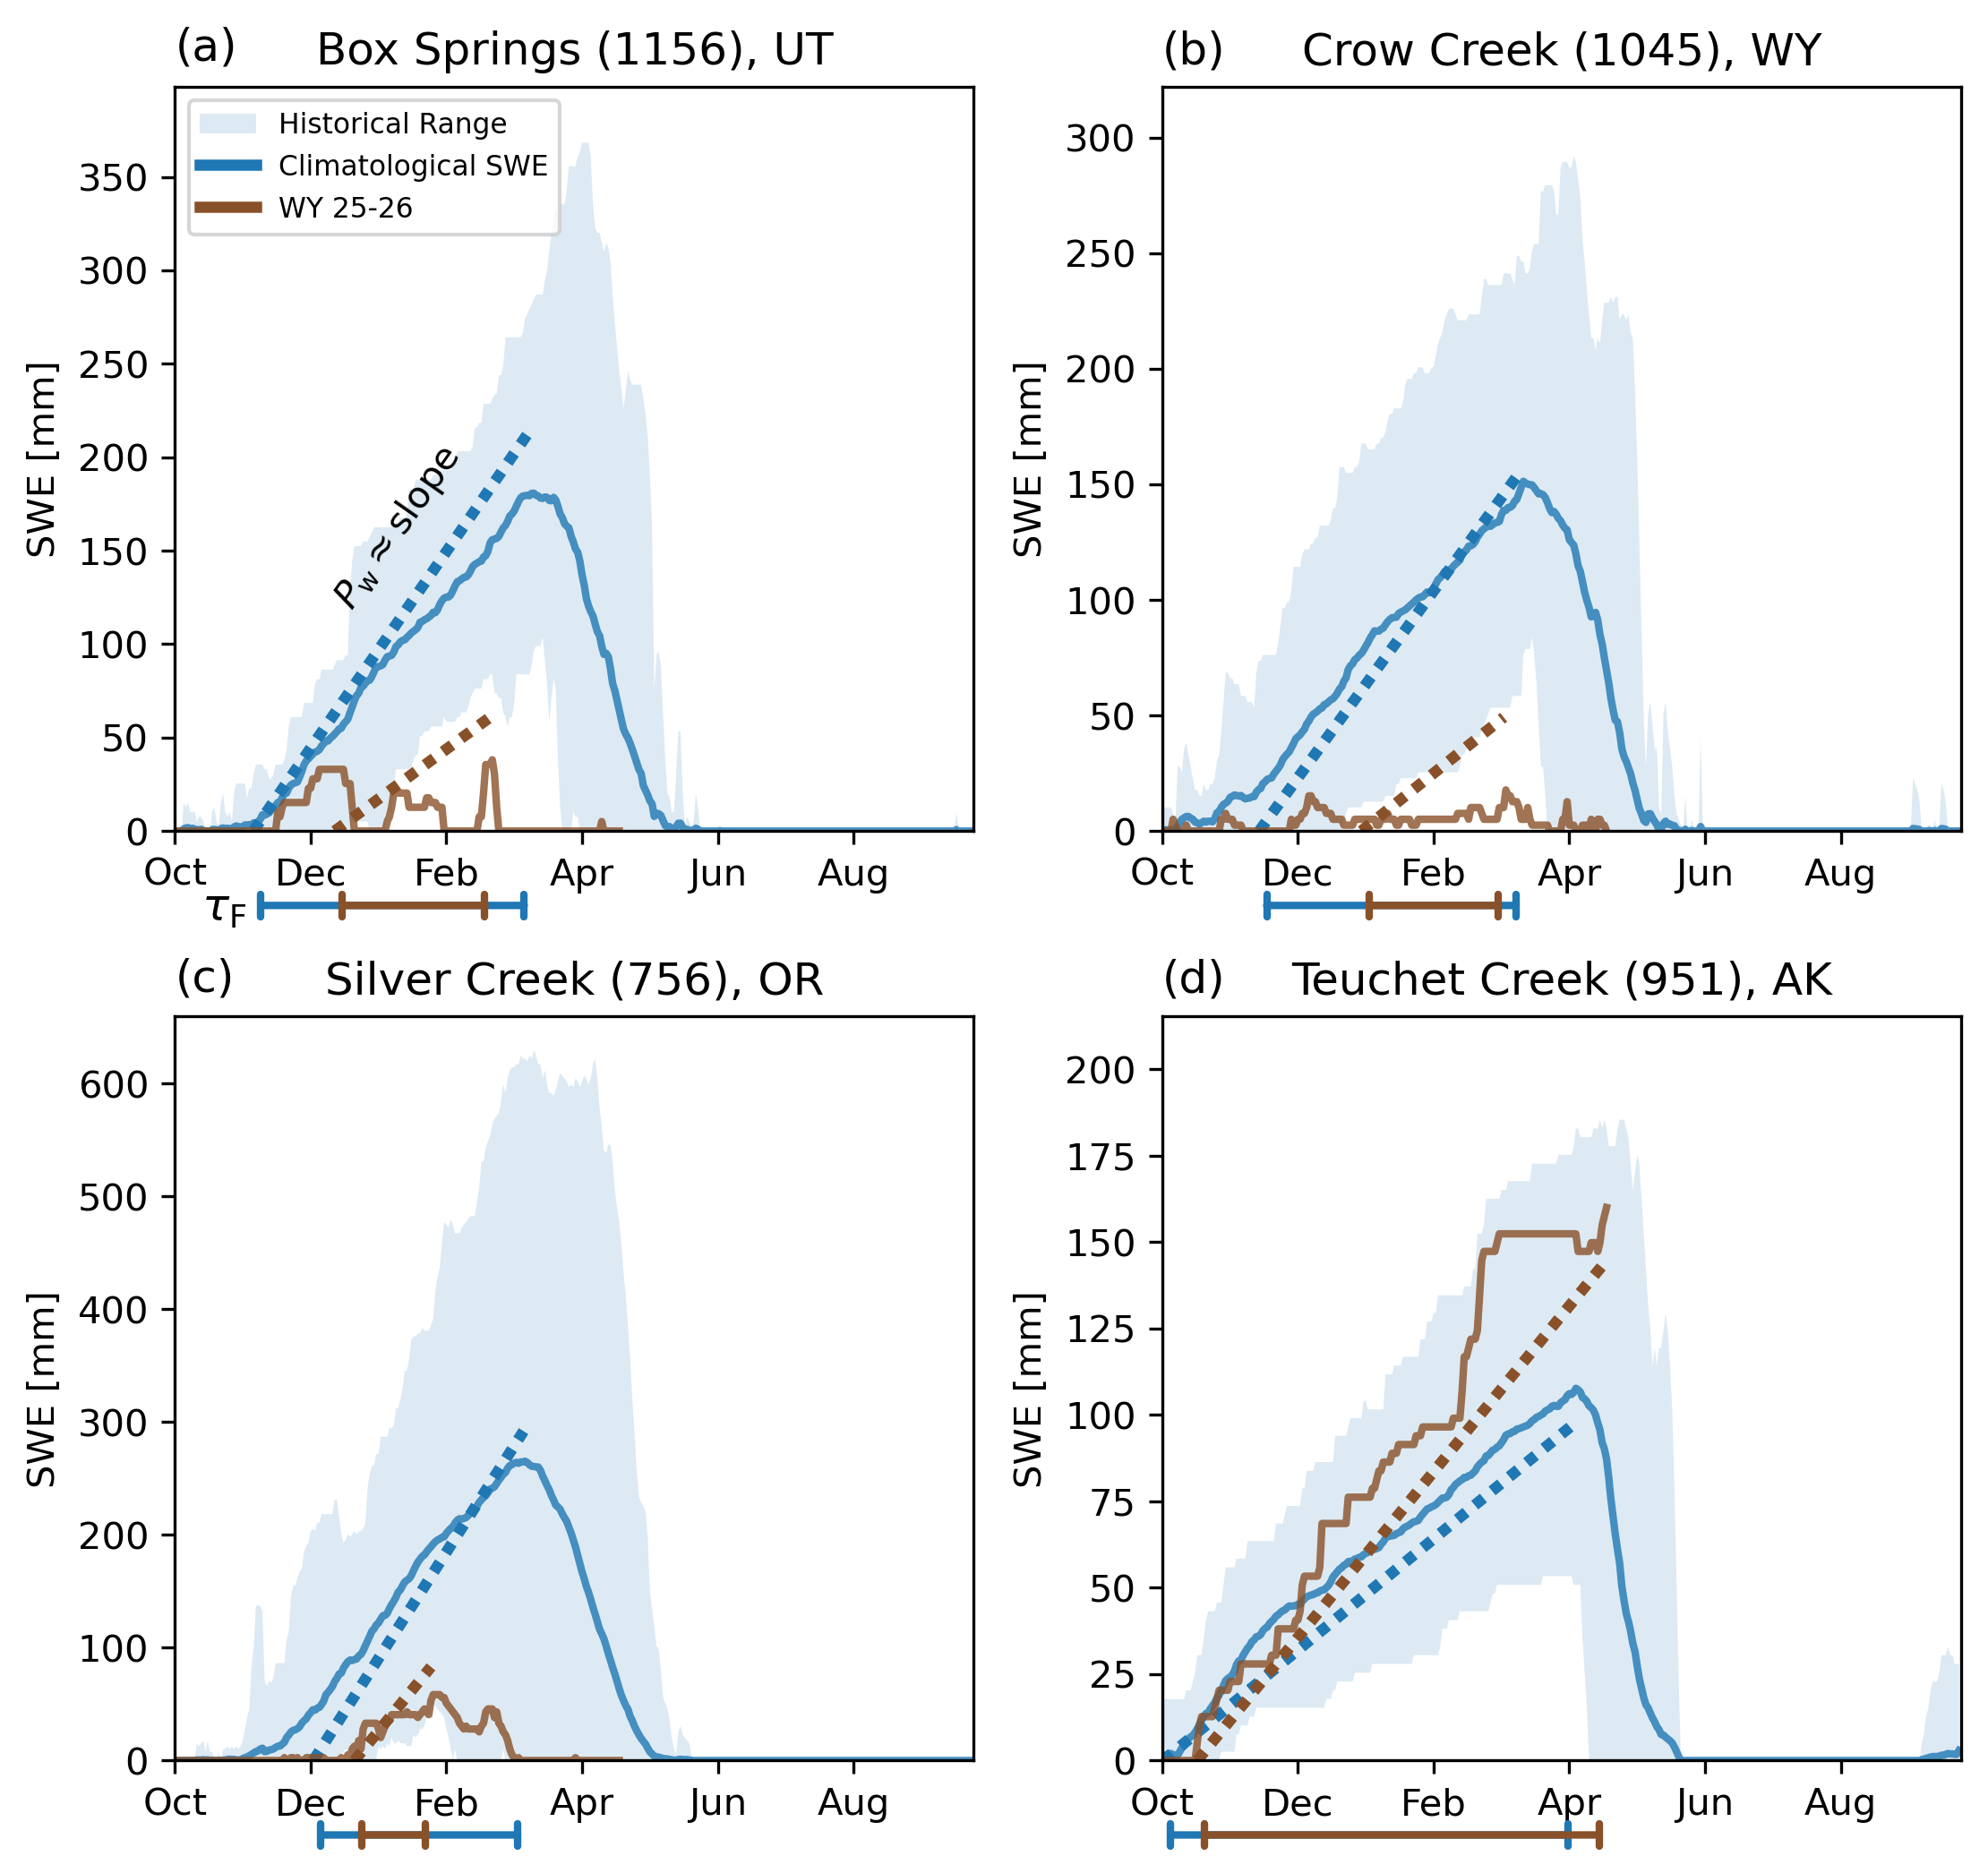

In [30]:
fig = plt.figure(figsize=(7.5,7),dpi=300)
gs = GridSpec(2,2)
annoFontSize = 10
tauFBarLevel = -.1

########################################
  ###### Station 1 Highlight ######
########################################
stationNumber = 1156
ax1 = fig.add_subplot(gs[0])

## Generate climatology for plot ##
stationClimSWE = stationLookupByNumber(stationNumber,climSWE_T_DICT)

climTime = np.arange(365)#stationClimSWE.dayofyear.values[waterYearInds]
climSWECycle = stationClimSWE.values[waterYearInds]
sweMaxCycle = stationClimSWE.sweMax.values[waterYearInds]
sweMinCycle = stationClimSWE.sweMin.values[waterYearInds]
climPw = PwClimArray[stationNumbers==stationNumber]
climTauF = tauFClimArray[stationNumbers==stationNumber]
climSWECycleMaxDay = np.argmax(climSWECycle)
clim_pwDomain = np.arange(climSWECycleMaxDay-climTauF,climSWECycleMaxDay)

## And data for the specific station ##
chosenStation = stationLookupByNumber(stationNumber,allStateDict_2526)
wy2526SWE = chosenStation.swe.values
wy2526Time = np.arange(len(wy2526SWE))
wy2526TauFDays = np.nonzero(chosenStation.T_avg.values<0)[0]
wy2526PeakSWEDay = np.argmax(wy2526SWE)
wy2526TauF = len(wy2526TauFDays)
wy2526Pw = chosenStation.Pw
wy2526_pwDomain = np.arange(wy2526PeakSWEDay-wy2526TauF,wy2526PeakSWEDay)

#### Plot of seasonal cycle ####
backgroundColor = 'tab:blue'#'#808080'

ax1.fill_between(climTime,sweMinCycle,sweMaxCycle,alpha=.15,facecolor=backgroundColor,label='Historical Range')
ax1.plot(climTime,climSWECycle,linewidth=2,c=backgroundColor,alpha=.8)
ax1.plot(np.arange(0,0),np.arange(0,0),c=backgroundColor,linestyle='-',linewidth=3,label='Climatological SWE')

ax1.plot(clim_pwDomain,np.arange(len(clim_pwDomain))*climPw,c=backgroundColor,linestyle=(0, (1, 1)),linewidth=3)

center = ((climSWECycleMaxDay-climTauF)[0],0)
p1 = (climSWECycleMaxDay,0)
p2 = (climSWECycleMaxDay,max(np.arange(len(clim_pwDomain))*climPw))
#AngleAnnotation(center,p1,p2,ax=ax1,size=200,color=backgroundColor)

trans = ax1.get_xaxis_transform()
plt.annotate("", xytext=(climSWECycleMaxDay-climTauF, tauFBarLevel), xy=(climSWECycleMaxDay, tauFBarLevel),xycoords=trans,
           arrowprops=dict(arrowstyle="|-|",edgecolor=backgroundColor,linewidth=2,mutation_scale=3))


#### WY Plot 25-26 ####
brownColor = '#895129'
chosenStation = stationLookupByNumber(stationNumber,allStateDict_2526)
ax1.plot(wy2526Time,wy2526SWE,linewidth=2,alpha=.8,c=brownColor)
ax1.plot(np.arange(0,0),np.arange(0,0),linestyle='-',linewidth=3,label='WY 25-26',c=brownColor)

ax1.plot(wy2526_pwDomain,np.arange(len(wy2526_pwDomain))*wy2526Pw,linestyle=(0, (1, 1)),c=brownColor,linewidth=3)
trans = ax1.get_xaxis_transform()
ax1.annotate("", xytext=(wy2526PeakSWEDay-wy2526TauF, tauFBarLevel), xy=(wy2526PeakSWEDay, tauFBarLevel),xycoords=trans,
           arrowprops=dict(arrowstyle="|-|",edgecolor=brownColor,linewidth=2,mutation_scale=3,linestyle='-'))
ax1.text(12,-48,r'$\tau_\text{F}$',fontsize=annoFontSize+2)

center = (wy2526PeakSWEDay-wy2526TauF,0)
p1 = (wy2526PeakSWEDay,0)
p2 = (wy2526PeakSWEDay,max(np.arange(len(wy2526_pwDomain))*wy2526Pw))
# AngleAnnotation(center, p1, p2, ax=ax1, size=200,color=brownColor,text=r"$\theta=\tan^{-1}(P_\text{w})$",textposition="edge",
#                text_kw=dict(xytext=(-45, -20),fontsize=annoFontSize))

ax1.legend(fontsize=7.5)
ax1.set_ylim([0,sweMaxCycle.max()+30])
ax1.set_xlim([0,365])
ax1.set_xticks(np.arange(0,359,62))
ax1.set_ylabel('SWE [mm]')
ax1.set_xticklabels(['Oct','Dec','Feb','Apr','Jun','Aug'],rotation=0);

# ann = ax1.annotate(r'$\text{SWE}_\text{max} \approx \tau_\text{F} P_\text{w}$',
#                   xy=(climSWECycleMaxDay, climTauF*climPw-10), xycoords='data',
#                   xytext=(300,400), textcoords='data',
#                   size=annoFontSize, va="center", ha="center",
#                   #bbox=dict(boxstyle="round4", fc="w"),
#                   arrowprops=dict(arrowstyle="-|>",
#                                   #connectionstyle="arc3,rad=0.2",
#                                   relpos=(0., .5),
#                                   fc="k"))

# ann = ax1.annotate(r"$\text{SWE}_\text{max} \approx \tau_\text{F} P_\text{w}$",
#                   xy=(wy2526PeakSWEDay, wy2526TauF*wy2526Pw+10), xycoords='data',
#                   xytext=(300,400), textcoords='data',
#                   size=annoFontSize, va="center", ha="center",
#                   #bbox=dict(boxstyle="round4", fc="w"),
#                   arrowprops=dict(arrowstyle="-|>",
#                                   relpos=(0,.5),
#                                   fc="k"))
ax1.set_title(chosenStation.name + f', {stationStates[stationNumbers==stationNumber][0]}')

ax1.text(70,120,r'$P_\text{w}\approx$slope',rotation=55,fontsize=annoFontSize)#90-np.atan((climTauF*climPw)/climSWECycleMaxDay)[0]*180/np.pi)

ax1.text(0,sweMaxCycle.max()+44,'(a)',fontsize=12)
########################################
  ###### Station 2 Highlight ######
########################################
stationNumber = 1045
ax1 = fig.add_subplot(gs[1])

## Generate climatology for plot ##
stationClimSWE = stationLookupByNumber(stationNumber,climSWE_T_DICT)

climTime = np.arange(365)#stationClimSWE.dayofyear.values[waterYearInds]
climSWECycle = stationClimSWE.values[waterYearInds]
sweMaxCycle = stationClimSWE.sweMax.values[waterYearInds]
sweMinCycle = stationClimSWE.sweMin.values[waterYearInds]
climPw = PwClimArray[stationNumbers==stationNumber]
climTauF = tauFClimArray[stationNumbers==stationNumber]
climSWECycleMaxDay = np.argmax(climSWECycle)
clim_pwDomain = np.arange(climSWECycleMaxDay-climTauF,climSWECycleMaxDay)

## And data for the specific station ##
chosenStation = stationLookupByNumber(stationNumber,allStateDict_2526)
wy2526SWE = chosenStation.swe.values
wy2526Time = np.arange(len(wy2526SWE))
wy2526TauFDays = np.nonzero(chosenStation.T_avg.values<0)[0]
wy2526PeakSWEDay = np.argmax(wy2526SWE)
wy2526TauF = len(wy2526TauFDays)
wy2526Pw = chosenStation.Pw
wy2526_pwDomain = np.arange(wy2526PeakSWEDay-wy2526TauF,wy2526PeakSWEDay)

#### Plot of seasonal cycle ####
backgroundColor = 'tab:blue'#'#808080'

ax1.fill_between(climTime,sweMinCycle,sweMaxCycle,alpha=.15,facecolor=backgroundColor,label='Historical Range')
ax1.plot(climTime,climSWECycle,linewidth=2,c=backgroundColor,alpha=.8)
ax1.plot(np.arange(0,0),np.arange(0,0),c=backgroundColor,linestyle='-',linewidth=3,label='Climatological SWE')

ax1.plot(clim_pwDomain,np.arange(len(clim_pwDomain))*climPw,c=backgroundColor,linestyle=(0, (1, 1)),linewidth=3)

center = ((climSWECycleMaxDay-climTauF)[0],0)
p1 = (climSWECycleMaxDay,0)
p2 = (climSWECycleMaxDay,max(np.arange(len(clim_pwDomain))*climPw))

trans = ax1.get_xaxis_transform()
plt.annotate("", xytext=(climSWECycleMaxDay-climTauF, tauFBarLevel), xy=(climSWECycleMaxDay, tauFBarLevel),xycoords=trans,
           arrowprops=dict(arrowstyle="|-|",edgecolor=backgroundColor,linewidth=2,mutation_scale=3))


#### WY Plot 25-26 ####
brownColor = '#895129'
chosenStation = stationLookupByNumber(stationNumber,allStateDict_2526)
ax1.plot(wy2526Time,wy2526SWE,linewidth=2,alpha=.8,c=brownColor)
ax1.plot(np.arange(0,0),np.arange(0,0),linestyle='-',linewidth=3,label='WY 25-26',c=brownColor)

ax1.plot(wy2526_pwDomain,np.arange(len(wy2526_pwDomain))*wy2526Pw,linestyle=(0, (1, 1)),c=brownColor,linewidth=3)
trans = ax1.get_xaxis_transform()
ax1.annotate("", xytext=(wy2526PeakSWEDay-wy2526TauF, tauFBarLevel), xy=(wy2526PeakSWEDay, tauFBarLevel),xycoords=trans,
           arrowprops=dict(arrowstyle="|-|",edgecolor=brownColor,linewidth=2,mutation_scale=3,linestyle='-'))

center = (wy2526PeakSWEDay-wy2526TauF,0)
p1 = (wy2526PeakSWEDay,0)
p2 = (wy2526PeakSWEDay,max(np.arange(len(wy2526_pwDomain))*wy2526Pw))

ax1.set_ylim([0,sweMaxCycle.max()+30])
ax1.set_xlim([0,365])
ax1.set_xticks(np.arange(0,359,62))
ax1.set_ylabel('SWE [mm]')
ax1.set_xticklabels(['Oct','Dec','Feb','Apr','Jun','Aug'],rotation=0);

ax1.set_title(chosenStation.name + f', {stationStates[stationNumbers==stationNumber][0]}')
ax1.text(0,sweMaxCycle.max()+40,'(b)',fontsize=12)


# ########################################
#   ###### Station 3 Highlight ######
# ########################################
stationNumber = 951
ax1 = fig.add_subplot(gs[3])

## Generate climatology for plot ##
stationClimSWE = stationLookupByNumber(stationNumber,climSWE_T_DICT)

climTime = np.arange(365)#stationClimSWE.dayofyear.values[waterYearInds]
climSWECycle = stationClimSWE.values[waterYearInds]
sweMaxCycle = stationClimSWE.sweMax.values[waterYearInds]
sweMinCycle = stationClimSWE.sweMin.values[waterYearInds]
climPw = PwClimArray[stationNumbers==stationNumber]
climTauF = tauFClimArray[stationNumbers==stationNumber]
climSWECycleMaxDay = np.argmax(climSWECycle)
clim_pwDomain = np.arange(climSWECycleMaxDay-climTauF,climSWECycleMaxDay)

## And data for the specific station ##
chosenStation = stationLookupByNumber(stationNumber,allStateDict_2526)
wy2526SWE = chosenStation.swe.values
wy2526Time = np.arange(len(wy2526SWE))
wy2526TauFDays = np.nonzero(chosenStation.T_avg.values<0)[0]
wy2526PeakSWEDay = np.argmax(wy2526SWE)
wy2526TauF = len(wy2526TauFDays)
wy2526Pw = chosenStation.Pw
wy2526_pwDomain = np.arange(wy2526PeakSWEDay-wy2526TauF,wy2526PeakSWEDay)

#### Plot of seasonal cycle ####
backgroundColor = 'tab:blue'#'#808080'

ax1.fill_between(climTime,sweMinCycle,sweMaxCycle,alpha=.15,facecolor=backgroundColor,label='Historical Range')
ax1.plot(climTime,climSWECycle,linewidth=2,c=backgroundColor,alpha=.8)
ax1.plot(np.arange(0,0),np.arange(0,0),c=backgroundColor,linestyle='-',linewidth=3,label='Climatological SWE')

ax1.plot(clim_pwDomain,np.arange(len(clim_pwDomain))*climPw,c=backgroundColor,linestyle=(0, (1, 1)),linewidth=3)

center = ((climSWECycleMaxDay-climTauF)[0],0)
p1 = (climSWECycleMaxDay,0)
p2 = (climSWECycleMaxDay,max(np.arange(len(clim_pwDomain))*climPw))
#AngleAnnotation(center,p1,p2,ax=ax1,size=200,color=backgroundColor)

trans = ax1.get_xaxis_transform()
plt.annotate("", xytext=(climSWECycleMaxDay-climTauF, tauFBarLevel), xy=(climSWECycleMaxDay, tauFBarLevel),xycoords=trans,
           arrowprops=dict(arrowstyle="|-|",edgecolor=backgroundColor,linewidth=2,mutation_scale=3))


#### WY Plot 25-26 ####
brownColor = '#895129'
chosenStation = stationLookupByNumber(stationNumber,allStateDict_2526)
ax1.plot(wy2526Time,wy2526SWE,linewidth=2,alpha=.8,c=brownColor)
ax1.plot(np.arange(0,0),np.arange(0,0),linestyle='-',linewidth=3,label='WY 25-26',c=brownColor)

ax1.plot(wy2526_pwDomain,np.arange(len(wy2526_pwDomain))*wy2526Pw,linestyle=(0, (1, 1)),c=brownColor,linewidth=3)
trans = ax1.get_xaxis_transform()
ax1.annotate("", xytext=(wy2526PeakSWEDay-wy2526TauF, tauFBarLevel), xy=(wy2526PeakSWEDay, tauFBarLevel),xycoords=trans,
           arrowprops=dict(arrowstyle="|-|",edgecolor=brownColor,linewidth=2,mutation_scale=3,linestyle='-'))

center = (wy2526PeakSWEDay-wy2526TauF,0)
p1 = (wy2526PeakSWEDay,0)
p2 = (wy2526PeakSWEDay,max(np.arange(len(wy2526_pwDomain))*wy2526Pw))

ax1.set_ylim([0,sweMaxCycle.max()+30])
ax1.set_xlim([0,365])
ax1.set_xticks(np.arange(0,359,62))
ax1.set_ylabel('SWE [mm]')
ax1.set_xticklabels(['Oct','Dec','Feb','Apr','Jun','Aug'],rotation=0);

ax1.set_title(chosenStation.name + f', {stationStates[stationNumbers==stationNumber][0]}')
ax1.text(0,sweMaxCycle.max()+37,'(d)',fontsize=12)

# ########################################
#   ###### Station 4 Highlight ######
# ########################################
stationNumber = 756
ax1 = fig.add_subplot(gs[2])

## Generate climatology for plot ##
stationClimSWE = stationLookupByNumber(stationNumber,climSWE_T_DICT)

climTime = np.arange(365)#stationClimSWE.dayofyear.values[waterYearInds]
climSWECycle = stationClimSWE.values[waterYearInds]
sweMaxCycle = stationClimSWE.sweMax.values[waterYearInds]
sweMinCycle = stationClimSWE.sweMin.values[waterYearInds]
climPw = PwClimArray[stationNumbers==stationNumber]
climTauF = tauFClimArray[stationNumbers==stationNumber]
climSWECycleMaxDay = np.argmax(climSWECycle)
clim_pwDomain = np.arange(climSWECycleMaxDay-climTauF,climSWECycleMaxDay)

## And data for the specific station ##
chosenStation = stationLookupByNumber(stationNumber,allStateDict_2526)
wy2526SWE = chosenStation.swe.values
wy2526Time = np.arange(len(wy2526SWE))
wy2526TauFDays = np.nonzero(chosenStation.T_avg.values<0)[0]
wy2526PeakSWEDay = np.argmax(wy2526SWE)
wy2526TauF = len(wy2526TauFDays)
wy2526Pw = chosenStation.Pw
wy2526_pwDomain = np.arange(wy2526PeakSWEDay-wy2526TauF,wy2526PeakSWEDay)

#### Plot of seasonal cycle ####
backgroundColor = 'tab:blue'#'#808080'

ax1.fill_between(climTime,sweMinCycle,sweMaxCycle,alpha=.15,facecolor=backgroundColor,label='Historical Range')
ax1.plot(climTime,climSWECycle,linewidth=2,c=backgroundColor,alpha=.8)
ax1.plot(np.arange(0,0),np.arange(0,0),c=backgroundColor,linestyle='-',linewidth=3,label='Climatological SWE')

ax1.plot(clim_pwDomain,np.arange(len(clim_pwDomain))*climPw,c=backgroundColor,linestyle=(0, (1, 1)),linewidth=3)

center = ((climSWECycleMaxDay-climTauF)[0],0)
p1 = (climSWECycleMaxDay,0)
p2 = (climSWECycleMaxDay,max(np.arange(len(clim_pwDomain))*climPw))

trans = ax1.get_xaxis_transform()
plt.annotate("", xytext=(climSWECycleMaxDay-climTauF, tauFBarLevel), xy=(climSWECycleMaxDay, tauFBarLevel),xycoords=trans,
           arrowprops=dict(arrowstyle="|-|",edgecolor=backgroundColor,linewidth=2,mutation_scale=3))


#### WY Plot 25-26 ####
brownColor = '#895129'
chosenStation = stationLookupByNumber(stationNumber,allStateDict_2526)
ax1.plot(wy2526Time,wy2526SWE,linewidth=2,alpha=.8,c=brownColor)
ax1.plot(np.arange(0,0),np.arange(0,0),linestyle='-',linewidth=3,label='WY 25-26',c=brownColor)

ax1.plot(wy2526_pwDomain,np.arange(len(wy2526_pwDomain))*wy2526Pw,linestyle=(0, (1, 1)),c=brownColor,linewidth=3)
trans = ax1.get_xaxis_transform()
ax1.annotate("", xytext=(wy2526PeakSWEDay-wy2526TauF, tauFBarLevel), xy=(wy2526PeakSWEDay, tauFBarLevel),xycoords=trans,
           arrowprops=dict(arrowstyle="|-|",edgecolor=brownColor,linewidth=2,mutation_scale=3,linestyle='-'))

center = (wy2526PeakSWEDay-wy2526TauF,0)
p1 = (wy2526PeakSWEDay,0)
p2 = (wy2526PeakSWEDay,max(np.arange(len(wy2526_pwDomain))*wy2526Pw))

ax1.set_ylim([0,sweMaxCycle.max()+30])
ax1.set_xlim([0,365])
ax1.set_xticks(np.arange(0,359,62))
ax1.set_ylabel('SWE [mm]')
ax1.set_xticklabels(['Oct','Dec','Feb','Apr','Jun','Aug'],rotation=0);

ax1.set_title(chosenStation.name + f', {stationStates[stationNumbers==stationNumber][0]}')
ax1.text(0,sweMaxCycle.max()+52,'(c)',fontsize=12)

plt.tight_layout()

saveFigBool = 0
if saveFigBool:
    plt.savefig(f'/home/nicknish/snowpack/snotelAnalysis/finalizedFigures/figureC1_wy26StatExmp.pdf')

# Supplement Figure: $\sigma$, $T_1$

Showing $\sigma$ and $T_1$, along with best fit line. 
Values are computed in T0overT1.ipynb [NOT IN FINAL PAPER]

In [32]:
### Load data ###
sigmaT1Data = np.load(pathToLoad + '/figureSupp_sigmaT1.npz')

stationApproxAmpsSin = sigmaT1Data['stationApproxAmpsSin']
stationWinterDailySTD = sigmaT1Data['stationWinterDailySTD']

## Also get Tw from figure 3 data ##
sensitivityData = np.load(pathToLoad + '/figure5AddedSen.npz')

Tw_stationClim = sensitivityData['TwClim']

In [33]:
## Plotting function adopted from the matplotlib documentation ##
def scatter_hist(x, y, ax, ax_histx, ax_histy):
    # no labels
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelleft=False)

    # the scatter plot:
    for_cBar = ax.scatter(x, y,c=Tw_stationClim,cmap='Oranges')


    binsY = np.linspace(min(y),max(y),12)
    binsX = np.linspace(min(x),max(x),12)
    ax_histx.hist(x, bins=binsX,facecolor='#899499')
    ax_histx.set_ylabel('Count')
    ax_histy.hist(y, bins=binsY, orientation='horizontal',facecolor='#899499')
    ax_histy.set_xlabel('Count')

    return for_cBar

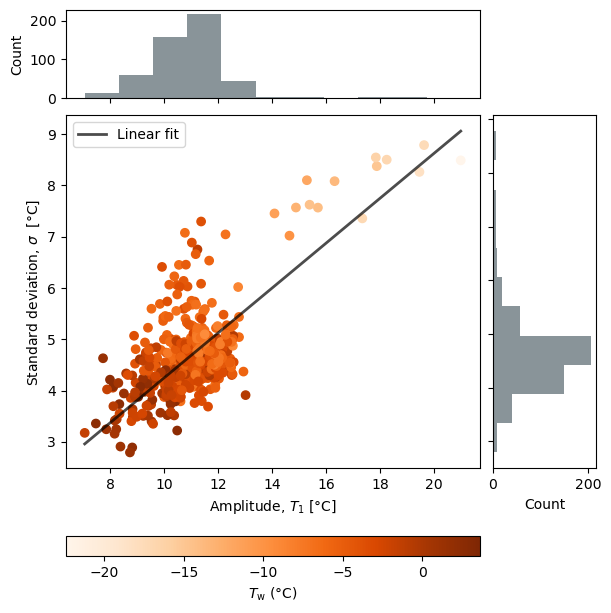

In [34]:
fig, axs = plt.subplot_mosaic([['histx', '.'],
                               ['scatter', 'histy']],
                              figsize=(6, 6),
                              width_ratios=(4, 1), height_ratios=(1, 4),
                              layout='constrained')
for_cBar = scatter_hist(stationApproxAmpsSin, stationWinterDailySTD, axs['scatter'], axs['histx'], axs['histy'])

cbar = fig.colorbar(for_cBar,location='bottom')
cbar.ax.set_xlabel(r'$T_\text{w}$ ($\degree$C)')

### Plot best fit curves ###
def f(B, x):
    '''Linear function y = m*x + b'''
    return B[0]*x + B[1]
linear = odr.Model(f)
mydata = odr.Data(stationApproxAmpsSin,stationWinterDailySTD)
myodr = odr.ODR(mydata, linear, beta0=[1., 2.])
odrParams = myodr.run()
bestFitDomain = np.linspace(min(stationApproxAmpsSin),max(stationApproxAmpsSin),100)
## Plot the ODR best fit ##
odrBestFitFunction = np.poly1d(odrParams.beta)
axs['scatter'].plot(bestFitDomain,odrBestFitFunction(bestFitDomain),label='Linear fit',linewidth=2,c='k',alpha = .7)
axs['scatter'].legend()

axs['scatter'].set_ylabel(r'Standard deviation, $\sigma$  [$\degree$C]')
axs['scatter'].set_xlabel(r'Amplitude, $T_1$ [$\degree$C]')


saveFigBool = 0
if saveFigBool:
    plt.savefig('....../figureSupp_sigmaT1.pdf',bbox_inches='tight')